# <font color = "red">**Deciphering the Decision Logic of an AI Agent**</font>

- Can we infer what an AI agent values by observing the sequence of decisions it makes?

- In this challenge, GPT acts as an autonomous microscopy agent that repeatedly selects one measurement location from a set of candidate AFM image patches.

- We record its decisions and then attempt to reverse-engineer the hidden logic behind those choices using visual, statistical, and data-driven methods.

<font color = "blue" size = 6>**Goal**</font>: develop a method that best explains GPT’s behavior and predicts its future decisions on unseen candidate sets.

<a href="https://colab.research.google.com/github/kbarakati/camm_hackathon/blob/k4my4r/docs/day_20_10092026/llm_decision_making.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports and reproducibility

In [ ]:
! pip install -q igor2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from igor2 import binarywave
import pickle

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

import random
np.random.seed(42)


Download data

In [ ]:
! gdown --folder "https://drive.google.com/drive/folders/1Gy7PeI4EhmlNE5hLxvP9p9A4u026QQ_X?usp=sharing"

## load data

In [3]:
fname = "/Users/borisslautin/Documents/GitHub/athena_camm_hackathon/docs/day_20_10092026/scan_main_0000.ibw"

ibw = binarywave.load(fname)

wave = ibw["wave"]

data = np.array(
    wave["wData"]
)

img_data = np.moveaxis(data,-1, 0)

channels = [
    "Height",
    "Amplitude1",
    "Amplitude2",
    "Phase1",
    "Phase2",
    "Frequency"
]

print("Channels:", channels)
print("Shape:", img_data.shape)
print("Mode: DART Mode")

Channels: ['Height', 'Amplitude1', 'Amplitude2', 'Phase1', 'Phase2', 'Frequency']
Shape: (6, 256, 256)
Mode: DART Mode


In [4]:
trace_files = [
    "/Users/borisslautin/Documents/GitHub/athena_camm_hackathon/docs/day_20_10092026/day_20_data/gpt_decision_trace_0.pkl",
    "/Users/borisslautin/Documents/GitHub/athena_camm_hackathon/docs/day_20_10092026/day_20_data/gpt_decision_trace_1.pkl",
    "/Users/borisslautin/Documents/GitHub/athena_camm_hackathon/docs/day_20_10092026/day_20_data/gpt_decision_trace_2.pkl",

    "/Users/borisslautin/Documents/GitHub/athena_camm_hackathon/docs/day_20_10092026/day_20_data/simulated_decision_trace_0.pkl",
    "/Users/borisslautin/Documents/GitHub/athena_camm_hackathon/docs/day_20_10092026/day_20_data/simulated_decision_trace_1.pkl",
    "/Users/borisslautin/Documents/GitHub/athena_camm_hackathon/docs/day_20_10092026/day_20_data/simulated_decision_trace_2.pkl",
    "/Users/borisslautin/Documents/GitHub/athena_camm_hackathon/docs/day_20_10092026/day_20_data/simulated_decision_trace_3.pkl",
    "/Users/borisslautin/Documents/GitHub/athena_camm_hackathon/docs/day_20_10092026/day_20_data/simulated_decision_trace_4.pkl",
    "/Users/borisslautin/Documents/GitHub/athena_camm_hackathon/docs/day_20_10092026/day_20_data/simulated_decision_trace_5.pkl",
    "/Users/borisslautin/Documents/GitHub/athena_camm_hackathon/docs/day_20_10092026/day_20_data/simulated_decision_trace_6.pkl",
    "/Users/borisslautin/Documents/GitHub/athena_camm_hackathon/docs/day_20_10092026/day_20_data/simulated_decision_trace_7.pkl",
]


traces = {}

for i, fname in enumerate(trace_files):

    with open(fname, "rb") as f:
        traces[i] = pickle.load(f)

Plot the AFM image

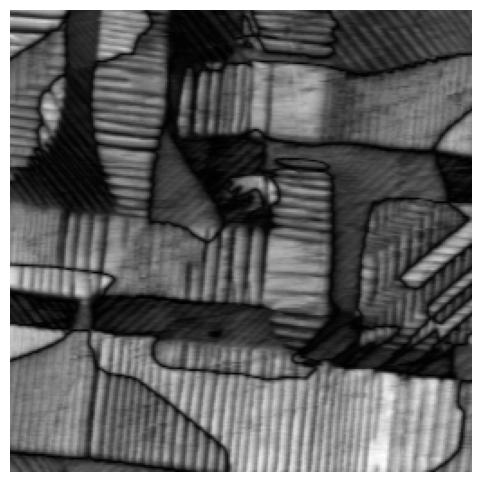

In [5]:
channel_index = 2 #--> we want amplitude

img = img_data[channel_index].T
img = (img - img.min()) / (img.max() - img.min())

plt.figure(figsize=(6, 6))

plt.imshow(
    img,
    cmap="gray"
)

plt.axis("off")
plt.show()

Each trace contains multiple decision steps.

For every step:

- `patches` contains all candidate image patches available to the agent.
- `selected_candidate` gives the candidate selected by the agent.
- `selected_patch` contains the selected image patch.
- `position` gives the selected location in the original AFM image.
- `score` may be available for some traces.

In [7]:
TRACE_ID = 4
STEP = 1

trace = traces[TRACE_ID]

step_data = trace[STEP - 1]

print("Selected candidate:",
      step_data["selected_candidate"])

print("Position:",
      step_data["position"])

print("Number of candidates:",
      len(step_data["patches"]))

if "score" in step_data:
    print("Score:",
          step_data["score"])

Selected candidate: 6
Position: (189, 183)
Number of candidates: 20
Score: 1.0


VISUALIZE ONE DECISION STEP

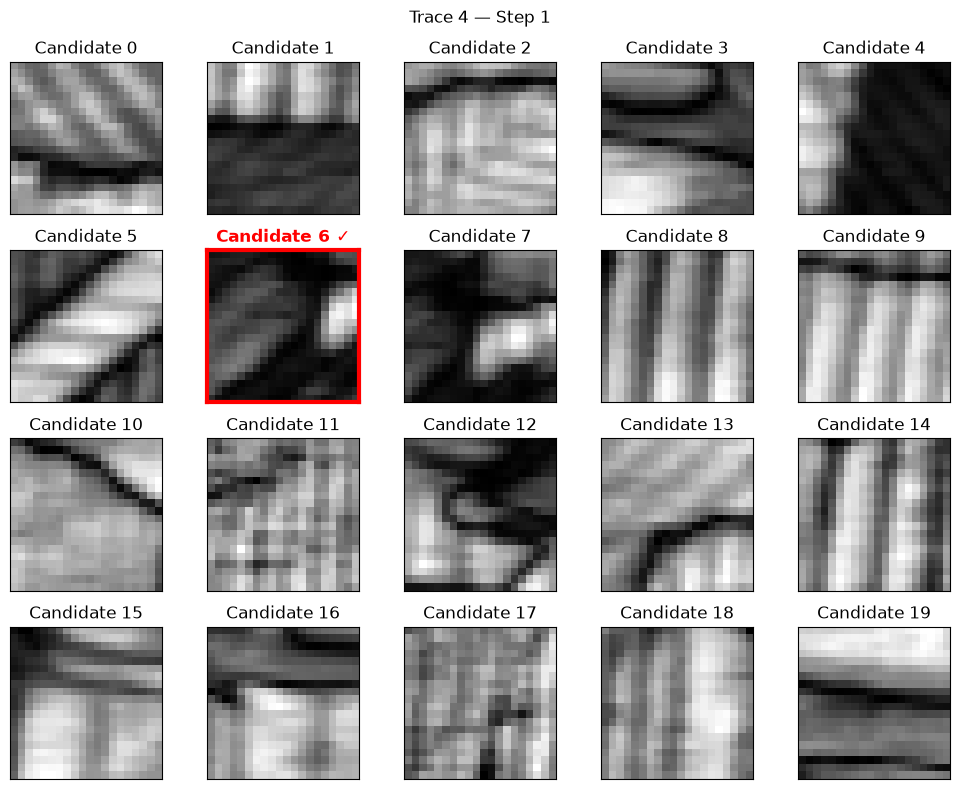

In [8]:
patches = step_data["patches"]
selected = step_data["selected_candidate"]

n = len(patches)

ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(10, 2 * nrows)
)

axes = np.array(axes).reshape(-1)

for i, ax in enumerate(axes):

    if i >= n:
        ax.axis("off")
        continue

    ax.imshow(
        patches[i],
        cmap="gray"
    )

    if i == selected:

        ax.set_title(
            f"Candidate {i} ✓",
            color="red",
            weight="bold"
        )

        for spine in ax.spines.values():
            spine.set_edgecolor("red")
            spine.set_linewidth(3)

    else:

        ax.set_title(
            f"Candidate {i}"
        )

    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(
    f"Trace {TRACE_ID} — Step {STEP}"
)

plt.tight_layout()
plt.show()

TRACE MAP ON ORIGINAL IMAGE

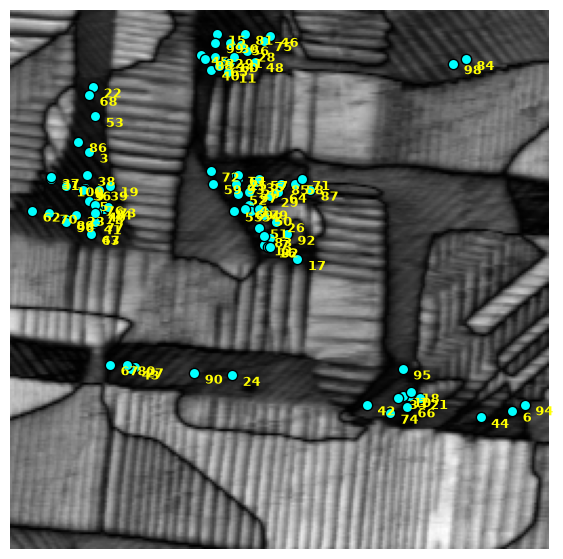

In [9]:
trace = traces[TRACE_ID]

steps = sorted(trace.keys())

xs = [
    trace[step]["position"][0]
    for step in steps
]

ys = [
    trace[step]["position"][1]
    for step in steps
]


fig, ax = plt.subplots(
    figsize=(7, 7)
)

ax.imshow(
    img,
    cmap="gray"
)


# ------------------------------------------------------------
# Plot all selected locations
# ------------------------------------------------------------

ax.scatter(
    xs,
    ys,
    s=55,
    color="cyan",
    edgecolors="black"
)


# ------------------------------------------------------------
# Label each point by decision step
# ------------------------------------------------------------

for step, x, y in zip(
    steps,
    xs,
    ys
):

    ax.text(
        x + 5,
        y + 5,
        str(step + 1),
        fontsize=9,
        color="yellow",
        weight="bold"
    )


ax.axis("off")

plt.show()

DECISION MAPS FOR 10 TRACES

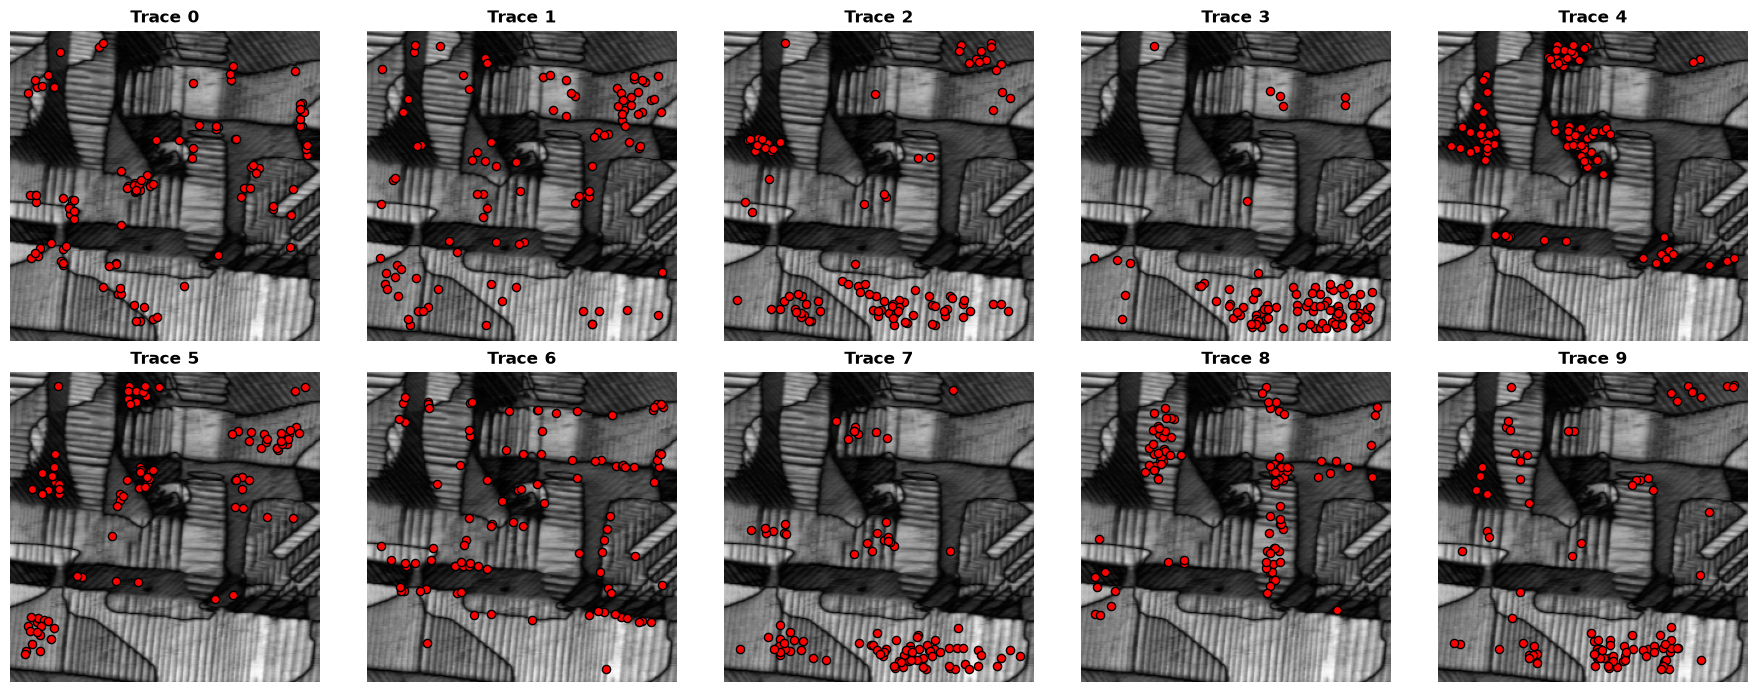

In [10]:
TRACE_IDS = list(traces.keys())[:10]

fig, axes = plt.subplots(
    2,
    5,
    figsize=(18, 7)
)

axes = axes.flatten()


for ax, trace_id in zip(axes, TRACE_IDS):

    trace = traces[trace_id]

    steps = sorted(trace.keys())

    xs = [
        trace[step]["position"][0]
        for step in steps
    ]

    ys = [
        trace[step]["position"][1]
        for step in steps
    ]


    # Original AFM image
    ax.imshow(
        img,
        cmap="gray"
    )


    # Selected locations
    ax.scatter(
        xs,
        ys,
        s=35,
        color="r",
        edgecolors="black"
    )

    ax.set_title(
        f"Trace {trace_id}",
        fontsize=12,
        weight="bold"
    )

    ax.axis("off")


plt.tight_layout()
plt.show()

# What Makes a Patch Get Selected?

Each decision step contains 20 candidate patches, but only one was selected.
The goal is to discover visual or quantitative characteristics that may explain the hidden objective.

## Method: Recovering the hidden reward from the agent's choices

**Idea:** every patch has a hidden "reward" value. At each step the agent sees 20 patches and picks the one with the highest reward. We see only which patch won, and we want to rebuild the reward function.

### Step 1. Build a latent space
- Cut  possible 20×20 patches from the full AFM image.
- Train a VAE on them.
- Every patch becomes a point `z` in a low-dimensional latent space.

### Step 2. Turn the decisions into data
- Each step = 20 points in latent space + the index of the winner.
- One step says: "the winner has a higher reward than the other 19".
- One trace = 100 steps

### Step 3. Likelihood: how well a guessed function explains the choices
- Take a guess for the reward function `f(z)`.
- For one step, the chance that the observed winner wins is:
  `P(winner) = exp(f(z_winner)/T) / sum over all 20 candidates of exp(f(z_i)/T)`
- `T` = noise level (small T = strict agent, large T = almost random agent).
- Likelihood of the whole trace = product of P(winner) over all 100 steps.

### Step 4. Prior: keep the function smooth
- Many functions can explain the winners, including spiky nonsense.
- Use a Gaussian Process (GP) prior: nearby points in latent space should have similar reward.
- One lengthscale per latent direction tells us which directions the reward cares about.

In [13]:
# ============================================================
# STEP 1a — CUT ALL POSSIBLE PATCHES FROM THE AFM IMAGE
# ============================================================
from numpy.lib.stride_tricks import sliding_window_view

# Patch size used by the agents (20 x 20 pixels)
PATCH = traces[0][0]["patches"][0].shape[0]
half = PATCH // 2

# Slide a 20x20 window over the image, moving 1 pixel at a time
windows = sliding_window_view(img.astype(np.float32), (PATCH, PATCH))
n_rows, n_cols = windows.shape[:2]

# All crops in one array: (number of crops, 20, 20)
all_crops = windows.reshape(-1, PATCH, PATCH).copy()

# Centre of each crop as (x, y) — same convention as step_data["position"]
rows, cols = np.meshgrid(np.arange(n_rows), np.arange(n_cols), indexing="ij")
crop_centers = np.stack([cols.ravel() + half, rows.ravel() + half], axis=1)

print("Number of crops:", len(all_crops))
print("Crop shape:", all_crops.shape[1:])

# Quick check: the first selected patch of trace 0 is one of our crops
x0, y0 = traces[0][0]["position"]
k = np.where((crop_centers[:, 0] == x0) & (crop_centers[:, 1] == y0))[0][0]
print("Crop matches the agent's patch:", np.allclose(all_crops[k], traces[0][0]["selected_patch"]))

Number of crops: 56169
Crop shape: (20, 20)
Crop matches the agent's patch: True


In [16]:
# ============================================================
# STEP 1b — DEFINE AND TRAIN A SMALL VAE
# ============================================================
import torch
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

LATENT_DIM = 8      # size of the latent space
EPOCHS = 15         # passes over all crops
BATCH = 256
SIGMA = 0.03        # expected pixel noise: smaller = sharper reconstructions, more detail kept

class VAE(nn.Module):

    def __init__(self, latent_dim):
        super().__init__()

        # Encoder: 20x20 patch -> 128 numbers
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.ReLU(),   # 20x20 -> 10x10
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),  # 10x10 -> 5x5
            nn.Flatten(),
            nn.Linear(64 * 5 * 5, 128), nn.ReLU()
        )

        # Latent position (mean) and its uncertainty (log variance)
        self.to_mu = nn.Linear(128, latent_dim)
        self.to_logvar = nn.Linear(128, latent_dim)

        # Decoder: latent point -> 20x20 patch
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 64 * 5 * 5), nn.ReLU(),
            nn.Unflatten(1, (64, 5, 5)),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(),  # 5x5 -> 10x10
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1)               # 10x10 -> 20x20
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.to_mu(h), self.to_logvar(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        # Pick a random point near mu (the "reparameterization trick")
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return self.decoder(z), mu, logvar


def vae_loss(x, x_rec, mu, logvar):
    # How badly the patch is reconstructed
    rec = ((x - x_rec) ** 2).sum(dim=(1, 2, 3)) / (2 * SIGMA ** 2)
    # How far the latent code is from a standard normal cloud
    kl = -0.5 * (1 + logvar - mu ** 2 - logvar.exp()).sum(dim=1)
    return (rec + kl).mean()


# Put crops into a tensor with a channel axis: (N, 1, 20, 20)
X_crops = torch.tensor(all_crops[:, None])

vae = VAE(LATENT_DIM).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(EPOCHS):

    # Shuffle crops each epoch
    order = torch.randperm(len(X_crops))
    total = 0.0

    for i in range(0, len(order), BATCH):
        xb = X_crops[order[i:i + BATCH]].to(device)

        x_rec, mu, logvar = vae(xb)
        loss = vae_loss(xb, x_rec, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total += loss.item() * len(xb)

    print(f"Epoch {epoch + 1:02d}/{EPOCHS}   loss = {total / len(X_crops):.1f}")

Epoch 01/15   loss = 6856.0
Epoch 02/15   loss = 2258.8
Epoch 03/15   loss = 1947.1
Epoch 04/15   loss = 1791.4
Epoch 05/15   loss = 1702.9
Epoch 06/15   loss = 1662.7
Epoch 07/15   loss = 1629.3
Epoch 08/15   loss = 1597.9
Epoch 09/15   loss = 1561.5
Epoch 10/15   loss = 1522.2
Epoch 11/15   loss = 1486.8
Epoch 12/15   loss = 1451.4
Epoch 13/15   loss = 1421.2
Epoch 14/15   loss = 1399.8
Epoch 15/15   loss = 1375.0


Latent array: (56169, 8)


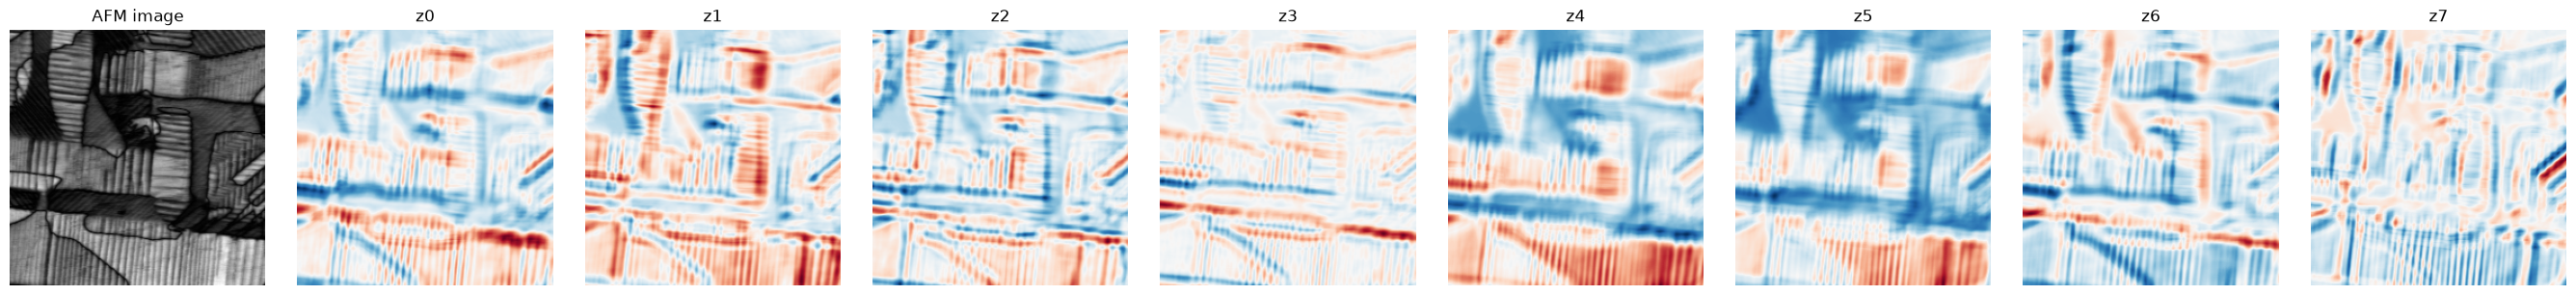

In [17]:
# ============================================================
# STEP 1c — ENCODE EVERY CROP INTO THE LATENT SPACE
# ============================================================

vae.eval()

Z_list = []
with torch.no_grad():
    for i in range(0, len(X_crops), 4096):
        mu, _ = vae.encode(X_crops[i:i + 4096].to(device))
        Z_list.append(mu.cpu().numpy())

# Latent coordinates of every crop: (number of crops, LATENT_DIM)
Z_all = np.concatenate(Z_list)
print("Latent array:", Z_all.shape)

# Each latent coordinate drawn as a map over the AFM image
fig, axes = plt.subplots(1, LATENT_DIM + 1, figsize=(3 * (LATENT_DIM + 1), 3))

axes[0].imshow(img[half:half + n_rows, half:half + n_cols], cmap="gray")
axes[0].set_title("AFM image")

for d in range(LATENT_DIM):
    axes[d + 1].imshow(Z_all[:, d].reshape(n_rows, n_cols), cmap="RdBu_r")
    axes[d + 1].set_title(f"z{d}")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# STEP 1d — CHECK: DID THE LATENT SPACE KEEP THE PHYSICS?
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

def patch_features(crops):
    # Simple, physically meaningful numbers for every patch
    crops = crops.astype(float)
    gy, gx = np.gradient(crops, axis=(1, 2))
    lap = (np.roll(crops, 1, 1) + np.roll(crops, -1, 1) +
           np.roll(crops, 1, 2) + np.roll(crops, -1, 2) - 4 * crops)[:, 1:-1, 1:-1]
    return pd.DataFrame({
        "mean":      crops.mean(axis=(1, 2)),
        "std":       crops.std(axis=(1, 2)),
        "max":       crops.max(axis=(1, 2)),
        "min":       crops.min(axis=(1, 2)),
        "gradient":  np.sqrt(gx ** 2 + gy ** 2).mean(axis=(1, 2)),
        "laplacian": np.abs(lap).mean(axis=(1, 2)),
    })

features_all = patch_features(all_crops)

# Use a random subset to keep it fast
rng_check = np.random.default_rng(0)
idx = rng_check.choice(len(Z_all), 10000, replace=False)

Z_train, Z_test, F_train, F_test = train_test_split(
    Z_all[idx], features_all.iloc[idx], test_size=0.3, random_state=0
)

# For each feature: can we predict it from the latent coordinates alone?
check = {}
for name in features_all.columns:
    knn = KNeighborsRegressor(n_neighbors=10).fit(Z_train, F_train[name])
    check[name] = r2_score(F_test[name], knn.predict(Z_test))

check = pd.Series(check, name="R² from latent")
print(check.round(3))

mean         0.991
std          0.912
max          0.881
min          0.902
gradient     0.779
laplacian    0.758
Name: R² from latent, dtype: float64


In [20]:
# ============================================================
# STEP 2 — TURN EVERY TRACE INTO DATA FOR THE REWARD MODEL
# ============================================================
# For every trace and every step we store:
#   Z        : latent coordinates of the 20 candidates   -> (steps, 20, LATENT_DIM)
#   winner   : index of the selected candidate            -> (steps,)
#   crop_idx : where each candidate sits in all_crops     -> (steps, 20)
#   xy       : (x, y) centre of each candidate on the map -> (steps, 20, 2)
#
# Every trace is kept separate, because each trace has its own reward function.

import os

# Readable names, taken from the file names in trace_files
trace_names = {
    t: os.path.splitext(os.path.basename(trace_files[t]))[0]
    for t in traces
}

# ------------------------------------------------------------
# Helper 1: find where a patch sits in the image
# ------------------------------------------------------------
# Fast way: exact match of the pixel values (dictionary lookup).
# Safe way (only if the fast way fails): closest crop by pixel difference.

crop_lookup = {}
for k, crop in enumerate(all_crops):
    crop_lookup.setdefault(crop.tobytes(), k)

print(f"Crops: {len(all_crops)}, unique crops: {len(crop_lookup)}")


def find_crop_index(patch):
    p = np.ascontiguousarray(patch, dtype=np.float32)

    # Fast exact match
    k = crop_lookup.get(p.tobytes())
    if k is not None:
        return k, 0.0

    # Fallback: closest crop (largest pixel difference should be ~0)
    diff = np.abs(all_crops - p).reshape(len(all_crops), -1).max(axis=1)
    k = int(np.argmin(diff))
    return k, float(diff[k])


# ------------------------------------------------------------
# Helper 2: latent coordinates of a list of patches
# ------------------------------------------------------------
# We encode the agent's patches directly with the VAE,
# so the result does not depend on the lookup above.

def encode_patches(patches):
    x = torch.tensor(np.asarray(patches, dtype=np.float32)[:, None]).to(device)
    with torch.no_grad():
        mu, _ = vae.encode(x)
    return mu.cpu().numpy()


# ------------------------------------------------------------
# Build the data for every trace
# ------------------------------------------------------------

trace_data = {}
problems = []          # every check that fails is written here
MATCH_TOL = 1e-4       # largest pixel difference we accept as "same patch"

for t, trace in traces.items():

    name = trace_names[t]
    steps = sorted(trace.keys())

    Z_steps, winners, idx_steps = [], [], []
    worst_diff = 0.0

    for s in steps:

        step_data = trace[s]
        patches = np.stack(step_data["patches"]).astype(np.float32)
        w = int(step_data["selected_candidate"])

        # Check 1: patch size is what we expect
        if patches.shape[1:] != (PATCH, PATCH):
            problems.append(f"{name} step {s}: patch shape {patches.shape[1:]}")

        # Check 2: the winner index is valid
        if not 0 <= w < len(patches):
            problems.append(f"{name} step {s}: winner index {w} out of range")
            continue

        # Check 3: stored selected patch is the same as patches[winner]
        if not np.allclose(patches[w], step_data["selected_patch"]):
            problems.append(f"{name} step {s}: selected_patch != patches[winner]")

        # Find every candidate in the image
        found = [find_crop_index(p) for p in patches]
        idx = np.array([k for k, _ in found])
        diffs = np.array([d for _, d in found])
        worst_diff = max(worst_diff, diffs.max())

        # Check 4: every candidate really is a crop of the image
        if diffs.max() > MATCH_TOL:
            problems.append(f"{name} step {s}: {np.sum(diffs > MATCH_TOL)} candidates not found in image")

        # Check 5: the stored position points to the winner's crop
        x, y = step_data["position"]
        pos_idx = (y - half) * n_cols + (x - half)
        if not np.allclose(all_crops[pos_idx], patches[w], atol=MATCH_TOL):
            problems.append(f"{name} step {s}: position {step_data['position']} does not match the winner")

        # Check 6: no identical candidates inside one step (would make a tie)
        if len(set(idx)) < len(idx):
            problems.append(f"{name} step {s}: duplicate candidates in this step")

        Z_steps.append(encode_patches(patches))
        winners.append(w)
        idx_steps.append(idx)

    idx_steps = np.array(idx_steps)

    trace_data[t] = {
        "name": name,
        "Z": np.stack(Z_steps),             # (steps, 20, LATENT_DIM)
        "winner": np.array(winners),        # (steps,)
        "crop_idx": idx_steps,              # (steps, 20)
        "xy": crop_centers[idx_steps],      # (steps, 20, 2)
        "worst_pixel_diff": worst_diff,
    }

# ------------------------------------------------------------
# Check 7: latent from direct encoding == latent from Step 1c
# ------------------------------------------------------------
for t, d in trace_data.items():
    gap = np.abs(d["Z"] - Z_all[d["crop_idx"]]).max()
    if gap > 1e-3:
        problems.append(f"{d['name']}: latent mismatch with Z_all (max diff {gap:.2e})")

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
summary = pd.DataFrame([
    {
        "trace": t,
        "name": d["name"],
        "steps": d["Z"].shape[0],
        "candidates/step": d["Z"].shape[1],
        "latent dim": d["Z"].shape[2],
        "worst pixel diff": d["worst_pixel_diff"],
    }
    for t, d in trace_data.items()
]).set_index("trace")

print(summary.to_string())

if problems:
    print(f"\n{len(problems)} PROBLEMS FOUND (showing first 20):")
    for p in problems[:20]:
        print("  -", p)
else:
    print("\nAll checks passed.")

Crops: 56169, unique crops: 56169
                             name  steps  candidates/step  latent dim  worst pixel diff
trace                                                                                  
0            gpt_decision_trace_0    100               20           8               0.0
1            gpt_decision_trace_1    100               20           8               0.0
2            gpt_decision_trace_2    100               20           8               0.0
3      simulated_decision_trace_0    100               20           8               0.0
4      simulated_decision_trace_1    100               20           8               0.0
5      simulated_decision_trace_2    100               20           8               0.0
6      simulated_decision_trace_3    100               20           8               0.0
7      simulated_decision_trace_4    100               20           8               0.0
8      simulated_decision_trace_5    100               20           8               0.

In [21]:
# ============================================================
# STEP 3a — THE LIKELIHOOD OF THE AGENT'S CHOICES
# ============================================================
# Input for one trace:
#   F       : reward value of every candidate     -> (steps, 20)
#   winners : index of the selected candidate     -> (steps,)
#   T       : noise level ("temperature"), T > 0
#
# Model: the chance that candidate i wins one step is
#   P(i) = exp(F_i / T) / sum over the 20 candidates of exp(F_j / T)
#
# Likelihood of the trace = product of P(winner) over all steps.
# We work with the log, so the product becomes a sum.

from scipy.special import logsumexp
from scipy.optimize import minimize_scalar

N_CAND = 20
LOGL_RANDOM_PER_STEP = -np.log(N_CAND)   # every candidate equally likely


def choice_probabilities(F, T=1.0):
    # Probability of every candidate to win, for every step -> (steps, 20)
    F = np.asarray(F, dtype=float)
    U = F / T
    return np.exp(U - logsumexp(U, axis=1, keepdims=True))


def choice_log_likelihood(F, winners, T=1.0):
    # log P(winner) for every step, and the total over all steps
    F = np.asarray(F, dtype=float)
    winners = np.asarray(winners)
    if T <= 0:
        raise ValueError("T must be positive")
    if F.shape[0] != len(winners):
        raise ValueError("F and winners must have the same number of steps")

    U = F / T
    # logsumexp is the safe way to compute log(sum(exp(...))) without overflow
    log_p = U[np.arange(len(winners)), winners] - logsumexp(U, axis=1)
    return log_p.sum(), log_p


def choice_log_likelihood_gradient(F, winners, T=1.0):
    # How the total log-likelihood changes when one reward value F_ij changes
    #   d logL / d F_ij = (1 if j is the winner else 0  -  P_ij) / T
    P = choice_probabilities(F, T)
    G = -P
    G[np.arange(len(winners)), winners] += 1.0
    return G / T


def choice_accuracy(F, winners, top_k=1):
    # Fraction of steps where the winner is among the top_k highest rewards.
    # Ties are handled fairly: if the winner shares the top place with
    # others, it gets only partial credit.
    F = np.asarray(F, dtype=float)
    credits = []
    for f, w in zip(F, winners):
        n_higher = np.sum(f > f[w])           # candidates clearly above the winner
        n_equal = np.sum(f == f[w])           # winner + candidates tied with it
        # how many of the tied places still fall inside the top_k
        free_places = top_k - n_higher
        credits.append(np.clip(free_places / n_equal, 0, 1))
    return float(np.mean(credits))


def fit_temperature(F, winners):
    # Best noise level T for a given reward guess F (only 1 number is fitted).
    # F is rescaled first so the search range is the same for every guess.
    F = np.asarray(F, dtype=float)
    scale = F.std()
    if scale == 0:
        # A constant reward explains nothing: same as random guessing
        return np.inf, len(winners) * LOGL_RANDOM_PER_STEP
    Fs = (F - F.mean()) / scale

    res = minimize_scalar(
        lambda logT: -choice_log_likelihood(Fs, winners, np.exp(logT))[0],
        bounds=(np.log(1e-3), np.log(1e3)),
        method="bounded",
    )
    T_best = np.exp(res.x) * scale            # back to the units of F
    logL_best = -res.fun

    # If the guess is no better than random, the best T is "infinite":
    # all candidates equally likely, exactly the random-guess likelihood
    logL_random = len(winners) * LOGL_RANDOM_PER_STEP
    if logL_best < logL_random:
        return np.inf, logL_random
    return T_best, logL_best


def explained_fraction(logL, n_steps):
    # 0 = no better than random guessing, 1 = every choice perfectly explained
    # (McFadden pseudo-R²)
    return 1 - logL / (n_steps * LOGL_RANDOM_PER_STEP)

In [22]:
# ============================================================
# STEP 3b — TEST THE LIKELIHOOD ON CASES WITH A KNOWN ANSWER
# ============================================================
# These tests use made-up numbers, not the AFM data.
# If any line says FAIL, do not continue.

test_rng = np.random.default_rng(1)
n_test = 100
F_test = test_rng.normal(size=(n_test, N_CAND))

def report(name, ok):
    print(f"{'PASS' if ok else 'FAIL'}  {name}")

# Test 1: a constant reward gives exactly the random-guess likelihood
logL, _ = choice_log_likelihood(np.zeros((n_test, N_CAND)), np.zeros(n_test, int))
report("constant reward = random guessing", np.isclose(logL, n_test * LOGL_RANDOM_PER_STEP))

# Test 2: probabilities in every step add up to 1
report("probabilities sum to 1", np.allclose(choice_probabilities(F_test, 0.7).sum(axis=1), 1))

# Test 3: adding a constant to all candidates of a step changes nothing
w_any = test_rng.integers(0, N_CAND, n_test)
shift = test_rng.normal(size=(n_test, 1)) * 100
report("adding a constant per step changes nothing",
       np.isclose(choice_log_likelihood(F_test, w_any)[0],
                  choice_log_likelihood(F_test + shift, w_any)[0]))

# Test 4: no overflow with huge values or tiny T
logL_big, _ = choice_log_likelihood(F_test * 1e6, w_any, T=1e-3)
report("no overflow with huge rewards", np.isfinite(logL_big))

# Test 5: the gradient formula agrees with a numerical derivative
G = choice_log_likelihood_gradient(F_test, w_any, T=0.5)
eps = 1e-6
i, j = 3, 7
F_plus = F_test.copy();  F_plus[i, j] += eps
F_minus = F_test.copy(); F_minus[i, j] -= eps
numeric = (choice_log_likelihood(F_plus, w_any, 0.5)[0] -
           choice_log_likelihood(F_minus, w_any, 0.5)[0]) / (2 * eps)
report("gradient matches numerical derivative", np.isclose(G[i, j], numeric, rtol=1e-5))

# Test 6: accuracy handles ties fairly (all equal -> 1/20 per step)
report("ties give partial credit",
       np.isclose(choice_accuracy(np.zeros((n_test, N_CAND)), w_any), 1 / N_CAND))

# Test 7: a strict agent that always picks the max -> accuracy 1, T goes to ~0
w_max = F_test.argmax(axis=1)
T_fit, logL_fit = fit_temperature(F_test, w_max)
report("strict agent: accuracy = 1", choice_accuracy(F_test, w_max) == 1.0)
report("strict agent: fitted T is small, explained fraction ~1",
       explained_fraction(logL_fit, n_test) > 0.95)

# Test 8: a noisy agent (true T = 0.5): fitted T should come back close to 0.5
n_big = 3000
F_big = test_rng.normal(size=(n_big, N_CAND))
P_true = choice_probabilities(F_big, T=0.5)
w_noisy = np.array([test_rng.choice(N_CAND, p=p) for p in P_true])
T_fit, _ = fit_temperature(F_big, w_noisy)
report(f"noisy agent: true T = 0.50, fitted T = {T_fit:.2f}", abs(T_fit - 0.5) < 0.05)

# Test 9: the true reward explains the choices better than a wrong reward
F_wrong = test_rng.normal(size=F_big.shape)
_, logL_true = fit_temperature(F_big, w_noisy)
_, logL_wrong = fit_temperature(F_wrong, w_noisy)
report("true reward beats a wrong reward", logL_true > logL_wrong)

PASS  constant reward = random guessing
PASS  probabilities sum to 1
PASS  adding a constant per step changes nothing
PASS  no overflow with huge rewards
PASS  gradient matches numerical derivative
PASS  ties give partial credit
PASS  strict agent: accuracy = 1
PASS  strict agent: fitted T is small, explained fraction ~1
PASS  noisy agent: true T = 0.50, fitted T = 0.50
PASS  true reward beats a wrong reward


In [ ]:
# ============================================================
# STEP 3c — USE THE LIKELIHOOD: SCORE SIMPLE GUESSES ON EVERY TRACE
# ============================================================
# A first look at the real traces before any reward model is fitted.
# For each simple guess ("the agent likes high mean", "likes low std", ...)
# we fit only the noise level T and see how well it explains the choices.
#
# explained = 0 -> no better than random, 1 -> every choice explained
# accuracy  = how often the highest-reward candidate is the real winner (random = 5%)
#
# Note: T is fitted on the same steps, so these are in-sample numbers.
# Fair, held-out testing comes in Step 6.

# Short names so the tables fit on screen: gpt0, gpt1, ..., sim0, sim1, ...
short = {
    t: d["name"].replace("gpt_decision_trace_", "gpt")
                .replace("simulated_decision_trace_", "sim")
    for t, d in trace_data.items()
}
order = [short[t] for t in trace_data]

rows = []

for t, d in trace_data.items():
    for feature in features_all.columns:

        # Reward value of every candidate = this feature of its patch
        values = features_all[feature].values[d["crop_idx"]]   # (steps, 20)

        for sign, label in [(+1, "high"), (-1, "low")]:
            F = sign * values
            T_fit, logL = fit_temperature(F, d["winner"])
            rows.append({
                "trace": short[t],
                "guess": f"{label} {feature}",
                "explained": explained_fraction(logL, len(d["winner"])),
                "accuracy": choice_accuracy(F, d["winner"]),
            })

guess_table = pd.DataFrame(rows)

# Best simple guess for every trace
best = (guess_table.sort_values("explained", ascending=False)
                   .groupby("trace", sort=False).head(1)
                   .set_index("trace")
                   .loc[order])

print("Best single-feature guess per trace:\n")
print(best.round(3).to_string())

# Full table: explained fraction for every guess and trace
print("\nExplained fraction for every guess:\n")
print(guess_table.pivot(index="trace", columns="guess", values="explained")
                 .loc[order]
                 .round(2).to_string())

In [ ]:
# ============================================================
# STEP 3d — SAME TEST, BUT WITH THE VAE LATENT COORDINATES
# ============================================================
# Guess: "the agent likes high (or low) values of one latent coordinate z_k".
# Same likelihood functions as in 3c, only the reward values come from Z.

rows = []

for t, d in trace_data.items():
    for k in range(LATENT_DIM):

        # Reward value of every candidate = its latent coordinate z_k
        values = d["Z"][:, :, k]                               # (steps, 20)

        for sign, label in [(+1, "high"), (-1, "low")]:
            F = sign * values
            T_fit, logL = fit_temperature(F, d["winner"])
            rows.append({
                "trace": short[t],
                "guess": f"{label} z{k}",
                "explained": explained_fraction(logL, len(d["winner"])),
                "accuracy": choice_accuracy(F, d["winner"]),
            })

latent_guess_table = pd.DataFrame(rows)

best_latent = (latent_guess_table.sort_values("explained", ascending=False)
                                 .groupby("trace", sort=False).head(1)
                                 .set_index("trace")
                                 .loc[order])

# Put the best physical-feature guess (3c) next to the best latent guess
compare = pd.DataFrame({
    "best feature":       best["guess"],
    "explained (feature)": best["explained"],
    "best latent":        best_latent["guess"],
    "explained (latent)": best_latent["explained"],
})

print(compare.round(3).to_string())

In [25]:
# ============================================================
# STEP 4a — THE SMOOTHNESS PRIOR: A GAUSSIAN PROCESS IN LATENT SPACE
# ============================================================
# The GP says: two patches that are close in latent space should have
# similar reward. "Close" is measured with a lengthscale:
#
#   k(z, z') = amplitude² * exp( -0.5 * |z - z'|² / lengthscale² )
#
#   lengthscale small -> reward can change quickly (detailed function)
#   lengthscale large -> reward changes slowly (simple, broad function)
#   amplitude         -> how big reward differences are.
#                        Only f / T enters the likelihood, so we fix T = 1
#                        and let the amplitude play the role of 1 / T:
#                        large amplitude = strict agent, small = noisy agent.
#
# We use ONE lengthscale for all latent directions. With only 100 choices
# per trace, 8 separate lengthscales would be poorly determined. Which
# directions matter is measured after fitting instead (Step 5e).

from scipy.spatial.distance import cdist

# ------------------------------------------------------------
# Standardize the latent coordinates (mean 0, std 1 per direction),
# so distances treat every direction equally
# ------------------------------------------------------------
Z_mean = Z_all.mean(axis=0)
Z_std = Z_all.std(axis=0)

Zs_all = (Z_all - Z_mean) / Z_std        # every crop, standardized


def gp_kernel(A, B, lengthscale, amplitude):
    # Covariance between every point in A and every point in B
    sq_dist = cdist(A, B, "sqeuclidean")
    return amplitude ** 2 * np.exp(-0.5 * sq_dist / lengthscale ** 2)


JITTER = 1e-6   # tiny number added to the diagonal so the matrix is safe to factorize


# ------------------------------------------------------------
# The set of DIFFERENT patches seen in a group of steps
# ------------------------------------------------------------
# The GP needs every patch once. If the same crop appears in two steps,
# it must get the same reward, so we keep it once and remember where
# it was used:
#
#   points   : indices into all_crops of the unique candidates  -> (n_points,)
#   step_map : for every step and candidate, which point it is  -> (steps, 20)
#              so the reward table is simply  F = f[step_map]

def unique_points(crop_idx_steps):
    points, inverse = np.unique(crop_idx_steps, return_inverse=True)
    step_map = inverse.reshape(crop_idx_steps.shape)
    # Check: going back through step_map gives the original crops
    assert np.array_equal(points[step_map], crop_idx_steps)
    return points, step_map


print(pd.Series({short[t]: len(unique_points(d["crop_idx"])[0]) for t, d in trace_data.items()},
                name="unique patches per trace").to_string())

gpt0    1968
gpt1    1968
gpt2    1965
sim0    1968
sim1    1968
sim2    1968
sim3    1968
sim4    1968
sim5    1968
sim6    1968
sim7    1968


In [ ]:
# ============================================================
# STEP 4b — LOOK AT THE PRIOR: WHAT KIND OF REWARD MAPS DOES IT ALLOW?
# ============================================================
# We draw random reward functions from the GP prior and paint them over
# the AFM image. Nothing is fitted here; it only shows what
# "smooth in latent space" means for different lengthscales.

# A coarse grid of crops (every 4th pixel) so the matrix stays small
grid_step = 4
on_grid = (((crop_centers[:, 0] - half) % grid_step == 0) &
           ((crop_centers[:, 1] - half) % grid_step == 0))
grid_idx = np.where(on_grid)[0]
grid_rows = len(np.unique(crop_centers[grid_idx, 1]))
grid_cols = len(np.unique(crop_centers[grid_idx, 0]))

prior_rng = np.random.default_rng(0)
test_lengthscales = [0.5, 1.0, 2.0, 4.0]

fig, axes = plt.subplots(1, len(test_lengthscales) + 1, figsize=(3.5 * (len(test_lengthscales) + 1), 3.5))

axes[0].imshow(img, cmap="gray")
axes[0].set_title("AFM image")

for ax, ls in zip(axes[1:], test_lengthscales):
    K = gp_kernel(Zs_all[grid_idx], Zs_all[grid_idx], ls, amplitude=1.0)
    L = np.linalg.cholesky(K + JITTER * np.eye(len(K)))
    f_sample = L @ prior_rng.standard_normal(len(K))      # one random reward function

    ax.imshow(f_sample.reshape(grid_rows, grid_cols), cmap="RdBu_r",
              extent=[half, half + n_cols, half + n_rows, half])
    ax.set_title(f"prior sample, lengthscale = {ls}")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# STEP 4c — BASELINE: A LINEAR REWARD IN LATENT SPACE
# ============================================================
# The simplest possible reward:  f(z) = w · z
# The agent walks "uphill" along one direction w of the latent space.
# We find w by maximizing the Step 3 likelihood (T = 1, size of w acts as 1/T).
# A small penalty on |w| keeps w finite when an agent is perfectly strict.

from scipy.optimize import minimize

L2_LINEAR = 0.01


def fit_linear_choice(Zs_steps, winners, l2=L2_LINEAR):
    # Zs_steps: (steps, 20, LATENT_DIM) standardized latent coordinates
    def objective(w):
        F = Zs_steps @ w                                       # (steps, 20)
        logL, _ = choice_log_likelihood(F, winners)
        G = choice_log_likelihood_gradient(F, winners)         # (steps, 20)
        grad = -np.einsum("sc,scd->d", G, Zs_steps) + l2 * w
        return -logL + 0.5 * l2 * w @ w, grad

    res = minimize(objective, np.zeros(Zs_steps.shape[2]), jac=True, method="L-BFGS-B")
    if not res.success:
        print("  warning: linear fit did not fully converge:", res.message)
    return res.x


linear_results = {}
rows = []

for t, d in trace_data.items():
    Zs_steps = Zs_all[d["crop_idx"]]                           # (steps, 20, LATENT_DIM)
    w = fit_linear_choice(Zs_steps, d["winner"])
    F = Zs_steps @ w
    logL, _ = choice_log_likelihood(F, d["winner"])

    linear_results[t] = w
    rows.append({
        "trace": short[t],
        "explained": explained_fraction(logL, len(d["winner"])),
        "accuracy": choice_accuracy(F, d["winner"]),
        "|w|": np.linalg.norm(w),
    })

linear_table = pd.DataFrame(rows).set_index("trace")
print("Linear reward in z (in-sample, i.e. measured on the same steps it was fitted on):\n")
print(linear_table.round(3).to_string())

print("\nDirection w for each trace (which latent coordinates the agent climbs):\n")
print(pd.DataFrame(linear_results, index=[f"z{k}" for k in range(LATENT_DIM)])
        .rename(columns=short).round(2).to_string())

Linear reward in z (in-sample, i.e. measured on the same steps it was fitted on):

       explained  accuracy     |w|
trace                             
gpt0       0.055      0.18   0.762
gpt1       0.031      0.10   0.499
gpt2       0.086      0.22   0.523
sim0       0.984      0.99  22.674
sim1       0.979      0.98  23.319
sim2       0.080      0.40   0.676
sim3       0.051      0.17   0.870
sim4       0.297      0.39   1.247
sim5       0.058      0.13   0.811
sim6       0.171      0.28   0.924
sim7       0.112      0.34   0.912

Direction w for each trace (which latent coordinates the agent climbs):

    gpt0  gpt1  gpt2   sim0   sim1  sim2  sim3  sim4  sim5  sim6  sim7
z0 -0.12 -0.00  0.25   2.03  -2.81  0.19  0.08 -0.33  0.00 -0.29  0.19
z1  0.01  0.03 -0.02   4.19  -6.24 -0.26 -0.03  0.26  0.56  0.10 -0.24
z2  0.10 -0.30  0.07  -0.27  -2.31 -0.00  0.39  0.10 -0.01  0.29 -0.16
z3 -0.09 -0.12 -0.11   0.25  -1.57 -0.24  0.46  0.15  0.03  0.16  0.55
z4  0.22  0.22  0.16  17.16 -16.2

In [28]:
# ============================================================
# STEP 5a — FIT THE GP REWARD (POSTERIOR MODE + LAPLACE EVIDENCE)
# ============================================================
# Unknowns: the reward f at every unique patch of the trace.
# We find the f that is most probable:
#
#     maximize   log-likelihood(f)  +  log-prior(f)
#                (explains winners)    (smooth in latent space)
#
# Trick for stable fitting: write f = L v, where K = L Lᵀ (Cholesky).
# Then the prior is simply 0.5 * |v|², and the problem has a single optimum.
#
# To choose lengthscale and amplitude we compute the "evidence"
# (Laplace approximation): how probable the observed choices are under
# these settings, averaged over all smooth functions. It automatically
# balances fit against complexity: too detailed or too simple both lose.

from scipy.linalg import solve_triangular


def gp_fit(crop_idx_steps, winners, lengthscale, amplitude):

    points, step_map = unique_points(crop_idx_steps)
    Zp = Zs_all[points]
    n = len(points)

    K = gp_kernel(Zp, Zp, lengthscale, amplitude)
    L = np.linalg.cholesky(K + JITTER * amplitude ** 2 * np.eye(n))

    # --- posterior mode: minimize  -logL(L v) + 0.5 |v|² ---
    def objective(v):
        f = L @ v
        F = f[step_map]
        logL, _ = choice_log_likelihood(F, winners)
        G = choice_log_likelihood_gradient(F, winners)
        g_points = np.bincount(step_map.ravel(), weights=G.ravel(), minlength=n)
        return -logL + 0.5 * v @ v, -L.T @ g_points + v

    res = minimize(objective, np.zeros(n), jac=True, method="L-BFGS-B",
                   options={"maxiter": 2000})

    v = res.x
    f = L @ v
    F = f[step_map]
    logL, _ = choice_log_likelihood(F, winners)

    # --- Laplace evidence ---
    # W = curvature of the log-likelihood; for one step it is diag(p) - p pᵀ
    P = choice_probabilities(F)                                 # (steps, 20)
    rows_L = L[step_map]                                        # (steps, 20, n)
    A = np.sqrt(P)[:, :, None] * rows_L                         # part from diag(p)
    b = np.einsum("sc,scn->sn", P, rows_L)                      # part from p pᵀ
    LtWL = (np.einsum("scn,scm->nm", A, A, optimize=True) - b.T @ b)
    B = np.eye(n) + LtWL
    sign, logdet = np.linalg.slogdet(B)
    evidence = logL - 0.5 * v @ v - 0.5 * logdet

    return {
        "points": points, "step_map": step_map,
        "lengthscale": lengthscale, "amplitude": amplitude,
        "L": L, "v": v, "f": f,
        # weights for predicting new points: f_new = k(new, points) @ alpha
        "alpha": solve_triangular(L.T, v, lower=False),
        "logL": logL, "evidence": evidence,
        "converged": res.success and sign > 0,
    }


def gp_predict(fit, crop_indices):
    # Reward of any crops (also ones the GP never saw), in chunks to save memory
    out = []
    for i in range(0, len(crop_indices), 5000):
        Zq = Zs_all[crop_indices[i:i + 5000]]
        Kq = gp_kernel(Zq, Zs_all[fit["points"]], fit["lengthscale"], fit["amplitude"])
        out.append(Kq @ fit["alpha"])
    return np.concatenate(out)


LENGTHSCALES = [0.5, 1.0, 2.0, 4.0]
AMPLITUDES = [1.0, 3.0, 10.0, 30.0]


def gp_fit_best(crop_idx_steps, winners, verbose=False):
    # Try every (lengthscale, amplitude) pair and keep the highest evidence
    best = None
    for ls in LENGTHSCALES:
        for amp in AMPLITUDES:
            fit = gp_fit(crop_idx_steps, winners, ls, amp)
            if verbose:
                print(f"  lengthscale {ls:4.1f}  amplitude {amp:5.1f}  evidence {fit['evidence']:9.2f}")
            if not fit["converged"]:
                continue
            if best is None or fit["evidence"] > best["evidence"]:
                best = fit
    return best

In [29]:
# ============================================================
# STEP 5b — TEST THE GP FIT ON A PLANTED REWARD WITH A KNOWN ANSWER
# ============================================================
# We invent a reward in latent space, let a strict agent choose with it
# on the real candidate sets of trace 3, and check that the GP recovers it.
# If any line says FAIL, do not continue.

test_trace = trace_data[3]
cidx = test_trace["crop_idx"]

# Invented reward: curved, uses two latent directions
def planted_reward(crop_indices):
    z = Zs_all[crop_indices]
    return 2.0 * z[..., 0] - (z[..., 1] - 0.5) ** 2

planted_winners = planted_reward(cidx).argmax(axis=1)       # strict agent

# Test 1: the gradient used inside gp_fit agrees with a numerical derivative
fit_check = gp_fit(cidx[:20], planted_winners[:20], 1.0, 3.0)
def J(v):
    F = (fit_check["L"] @ v)[fit_check["step_map"]]
    return -choice_log_likelihood(F, planted_winners[:20])[0] + 0.5 * v @ v
v0 = np.random.default_rng(0).normal(size=len(fit_check["v"]))
F0 = (fit_check["L"] @ v0)[fit_check["step_map"]]
G0 = choice_log_likelihood_gradient(F0, planted_winners[:20])
g_pts = np.bincount(fit_check["step_map"].ravel(), weights=G0.ravel(), minlength=len(v0))
grad_formula = -fit_check["L"].T @ g_pts + v0
e = np.zeros_like(v0); e[5] = 1e-6
grad_numeric = (J(v0 + e) - J(v0 - e)) / 2e-6
report("GP gradient matches numerical derivative", np.isclose(grad_formula[5], grad_numeric, rtol=1e-4))

# Test 2: fit on 80 steps, predict the 20 hidden steps
train, test = np.arange(80), np.arange(80, 100)
fit_planted = gp_fit_best(cidx[train], planted_winners[train])
F_test_pred = gp_predict(fit_planted, cidx[test].ravel()).reshape(len(test), -1)
acc = choice_accuracy(F_test_pred, planted_winners[test])
report(f"planted reward: hidden-step accuracy = {acc:.0%} (random = 5%)", acc >= 0.6)

# Test 3: the recovered reward ranks ALL crops like the planted one
from scipy.stats import spearmanr
sample = np.random.default_rng(0).choice(len(Zs_all), 3000, replace=False)
rho = spearmanr(gp_predict(fit_planted, sample), planted_reward(sample)).correlation
report(f"planted reward: rank correlation over the whole image = {rho:.2f}", rho > 0.7)

# Test 4: random choices -> the GP should NOT find a strong reward
random_winners = np.random.default_rng(1).integers(0, N_CAND, len(cidx))
fit_random = gp_fit_best(cidx[train], random_winners[train])
F_rand = gp_predict(fit_random, cidx[test].ravel()).reshape(len(test), -1)
acc_rand = choice_accuracy(F_rand, random_winners[test])
report(f"random agent: hidden-step accuracy = {acc_rand:.0%} (should be near 5%)", acc_rand <= 0.25)

PASS  GP gradient matches numerical derivative
PASS  planted reward: hidden-step accuracy = 80% (random = 5%)
PASS  planted reward: rank correlation over the whole image = 0.93
PASS  random agent: hidden-step accuracy = 0% (should be near 5%)


In [30]:
# ============================================================
# STEP 5c — FIT THE GP REWARD FOR EVERY TRACE
# ============================================================
# Each trace gets its own reward function (fitted on all its steps).
# The table shows in-sample numbers: a flexible GP can look very good
# on the steps it was fitted on, so ALWAYS also look at 5d.

gp_results = {}
rows = []

for t, d in trace_data.items():
    fit = gp_fit_best(d["crop_idx"], d["winner"])
    gp_results[t] = fit
    F = fit["f"][fit["step_map"]]
    rows.append({
        "trace": short[t],
        "lengthscale": fit["lengthscale"],
        "amplitude": fit["amplitude"],
        "evidence": fit["evidence"],
        "explained (in-sample)": explained_fraction(fit["logL"], len(d["winner"])),
        "accuracy (in-sample)": choice_accuracy(F, d["winner"]),
    })
    print(f"{short[t]} done")

gp_table = pd.DataFrame(rows).set_index("trace")
print()
print(gp_table.round(3).to_string())

gpt0 done
gpt1 done
gpt2 done
sim0 done
sim1 done
sim2 done
sim3 done
sim4 done
sim5 done
sim6 done
sim7 done

       lengthscale  amplitude  evidence  explained (in-sample)  accuracy (in-sample)
trace                                                                               
gpt0           1.0        3.0  -276.954                  0.763                  0.96
gpt1           1.0        1.0  -284.589                  0.258                  0.39
gpt2           1.0        3.0  -220.840                  0.725                  0.81
sim0           4.0       30.0   -45.202                  0.988                  1.00
sim1           4.0       30.0   -30.117                  0.980                  0.99
sim2           1.0       10.0  -102.237                  0.944                  0.99
sim3           2.0        3.0  -219.196                  0.652                  0.72
sim4           2.0        3.0  -197.163                  0.636                  0.69
sim5           1.0        3.0  -238.203

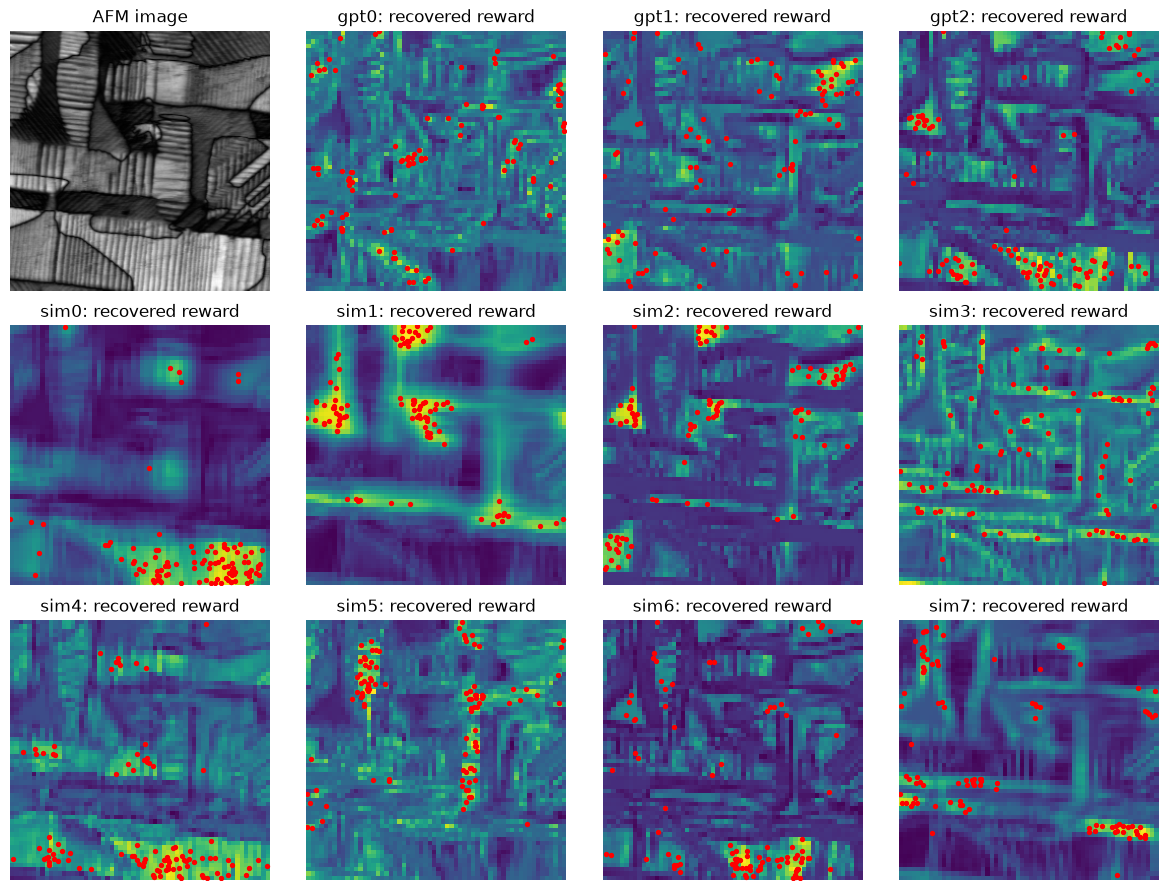

Share of the reward's slope along each latent direction (columns sum to 1):

    gpt0  gpt1  gpt2  sim0  sim1  sim2  sim3  sim4  sim5  sim6  sim7
z0  0.15  0.16  0.13  0.08  0.07  0.14  0.11  0.12  0.11  0.14  0.15
z1  0.11  0.14  0.12  0.12  0.14  0.10  0.11  0.09  0.14  0.12  0.14
z2  0.13  0.10  0.14  0.06  0.08  0.14  0.12  0.07  0.13  0.13  0.13
z3  0.11  0.13  0.12  0.05  0.04  0.15  0.17  0.14  0.12  0.12  0.11
z4  0.11  0.11  0.11  0.23  0.29  0.14  0.15  0.12  0.11  0.12  0.07
z5  0.13  0.14  0.11  0.30  0.23  0.12  0.11  0.20  0.15  0.11  0.16
z6  0.12  0.12  0.14  0.06  0.08  0.11  0.12  0.13  0.12  0.13  0.17
z7  0.14  0.12  0.13  0.10  0.07  0.10  0.11  0.12  0.12  0.13  0.07


In [34]:
# ============================================================
# STEP 5e — LOOK AT THE RECOVERED REWARD (ALL TRACES)
# ============================================================
# (1) Reward maps: the fitted reward of every crop, painted over the image,
#     one panel per trace, with the agent's selected patches as red dots.
# (2) Which latent directions matter: average size of the slope of the
#     reward along each direction z_k (larger = the agent cares more).
# Uses gp_results from 5c — nothing is retrained.

trace_ids = list(trace_data.keys())

# One panel for the AFM image + one panel per trace
n_panels = len(trace_ids) + 1
ncols = 4
nrows = int(np.ceil(n_panels / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows), dpi=100)
axes = axes.ravel()

# First panel: the AFM image for reference
axes[0].imshow(img, cmap="gray")
axes[0].set_title("AFM image")

for ax, t in zip(axes[1:], trace_ids):
    fit = gp_results[t]
    d = trace_data[t]

    # Reward of every crop on the coarse grid from 4b
    reward_grid = gp_predict(fit, grid_idx).reshape(grid_rows, grid_cols)

    # (x, y) of the patch the agent selected at each step
    winners_xy = d["xy"][np.arange(len(d["winner"])), d["winner"]]

    ax.imshow(reward_grid, cmap="viridis",
              extent=[half, half + n_cols, half + n_rows, half])
    ax.scatter(winners_xy[:, 0], winners_xy[:, 1], s=8, c="red")
    ax.set_title(f"{short[t]}: recovered reward")

# Hide unused panels and all axes ticks
for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

# (2) slope of the reward along each latent direction, at the patches the agent saw
def latent_relevance(fit):
    Zp = Zs_all[fit["points"]]
    K = gp_kernel(Zp, Zp, fit["lengthscale"], fit["amplitude"])
    slopes = []
    for k in range(LATENT_DIM):
        diff = Zp[:, k][None, :] - Zp[:, k][:, None]          # z_k(point j) - z_k(point i)
        slope_k = (K * diff / fit["lengthscale"] ** 2) @ fit["alpha"]
        slopes.append(np.mean(np.abs(slope_k)))
    slopes = np.array(slopes)
    return slopes / slopes.sum()

relevance = pd.DataFrame({short[t]: latent_relevance(gp_results[t]) for t in trace_ids},
                         index=[f"z{k}" for k in range(LATENT_DIM)])
print("Share of the reward's slope along each latent direction (columns sum to 1):\n")
print(relevance.round(2).to_string())

In [35]:
# ============================================================
# STEP 5d — QUICK HONEST CHECK: PREDICT STEPS THE MODEL HAS NOT SEEN
# ============================================================
# Fit on the first 80 steps, predict the winner of the last 20 steps.
# Same split for the linear baseline and the GP, so they are comparable.
# (Step 6 will do this more thoroughly, rotating which steps are hidden.)

train, test = np.arange(80), np.arange(80, 100)
rows = []

for t, d in trace_data.items():
    cidx, win = d["crop_idx"], d["winner"]

    # Linear baseline
    w = fit_linear_choice(Zs_all[cidx[train]], win[train])
    F_lin = Zs_all[cidx[test]] @ w

    # GP
    fit = gp_fit_best(cidx[train], win[train])
    F_gp = gp_predict(fit, cidx[test].ravel()).reshape(len(test), -1)

    rows.append({
        "trace": short[t],
        "linear: hidden accuracy": choice_accuracy(F_lin, win[test]),
        "GP: hidden accuracy": choice_accuracy(F_gp, win[test]),
        "GP: hidden top-3": choice_accuracy(F_gp, win[test], top_k=3),
    })

holdout_table = pd.DataFrame(rows).set_index("trace")
print("Accuracy on 20 hidden steps (random = 5%, random top-3 = 15%):\n")
print(holdout_table.round(2).to_string())
print("\nWith 20 hidden steps, each step is worth 5%, so small differences are noise.")

Accuracy on 20 hidden steps (random = 5%, random top-3 = 15%):

       linear: hidden accuracy  GP: hidden accuracy  GP: hidden top-3
trace                                                                
gpt0                      0.30                 0.30              0.55
gpt1                      0.05                 0.20              0.35
gpt2                      0.25                 0.40              0.60
sim0                      0.95                 0.95              1.00
sim1                      1.00                 0.90              1.00
sim2                      0.45                 0.75              1.00
sim3                      0.20                 0.30              0.70
sim4                      0.35                 0.40              0.65
sim5                      0.15                 0.30              0.50
sim6                      0.25                 0.40              0.75
sim7                      0.45                 0.60              0.85

With 20 hidden steps, eac

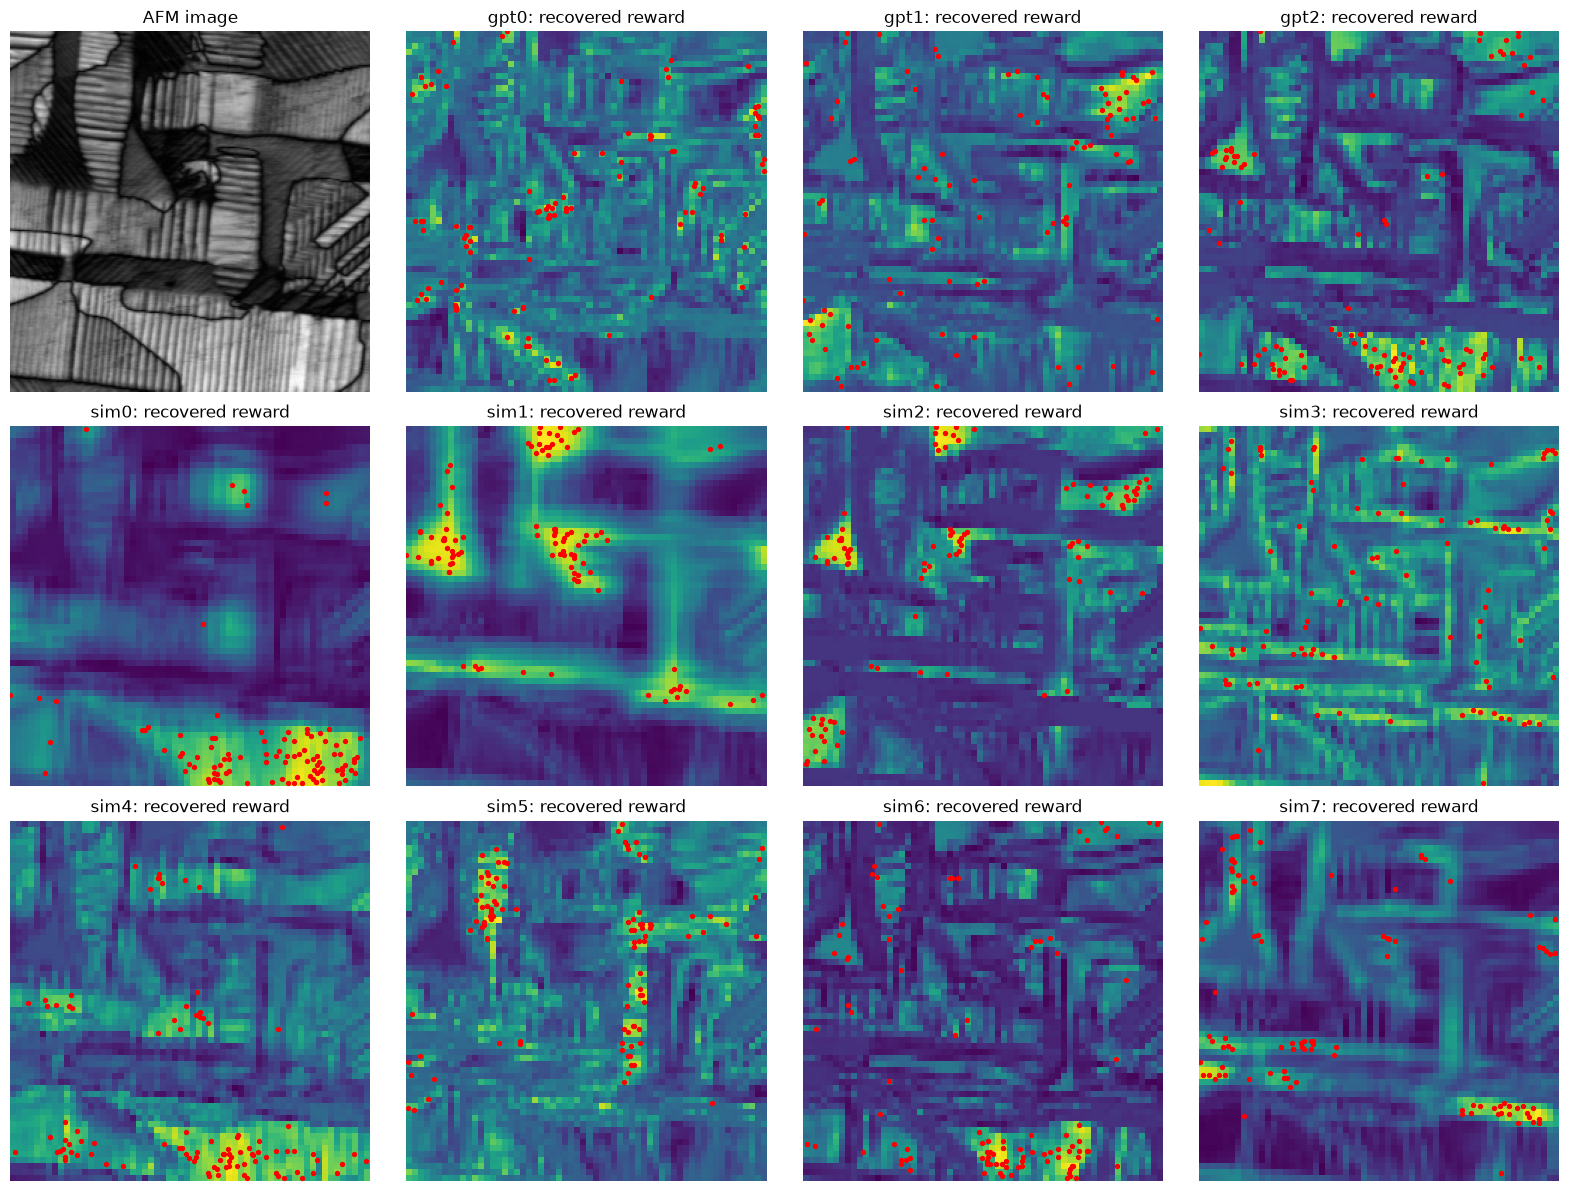

Share of the reward's slope along each latent direction (columns sum to 1):

    gpt0  gpt1  gpt2  sim0  sim1  sim2  sim3  sim4  sim5  sim6  sim7
z0  0.15  0.16  0.13  0.08  0.07  0.14  0.11  0.12  0.11  0.14  0.15
z1  0.11  0.14  0.12  0.12  0.14  0.10  0.11  0.09  0.14  0.12  0.14
z2  0.13  0.10  0.14  0.06  0.08  0.14  0.12  0.07  0.13  0.13  0.13
z3  0.11  0.13  0.12  0.05  0.04  0.15  0.17  0.14  0.12  0.12  0.11
z4  0.11  0.11  0.11  0.23  0.29  0.14  0.15  0.12  0.11  0.12  0.07
z5  0.13  0.14  0.11  0.30  0.23  0.12  0.11  0.20  0.15  0.11  0.16
z6  0.12  0.12  0.14  0.06  0.08  0.11  0.12  0.13  0.12  0.13  0.17
z7  0.14  0.12  0.13  0.10  0.07  0.10  0.11  0.12  0.12  0.13  0.07


In [36]:
# ============================================================
# STEP 5e — LOOK AT THE RECOVERED REWARD (ALL TRACES)
# ============================================================
# (1) Reward maps: the fitted reward of every crop, painted over the image,
#     one panel per trace, with the agent's selected patches as red dots.
# (2) Which latent directions matter: average size of the slope of the
#     reward along each direction z_k (larger = the agent cares more).
# Uses gp_results from 5c — nothing is retrained.

trace_ids = list(trace_data.keys())

# One panel for the AFM image + one panel per trace
n_panels = len(trace_ids) + 1
ncols = 4
nrows = int(np.ceil(n_panels / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.ravel()

# First panel: the AFM image for reference
axes[0].imshow(img, cmap="gray")
axes[0].set_title("AFM image")

for ax, t in zip(axes[1:], trace_ids):
    fit = gp_results[t]
    d = trace_data[t]

    # Reward of every crop on the coarse grid from 4b
    reward_grid = gp_predict(fit, grid_idx).reshape(grid_rows, grid_cols)

    # (x, y) of the patch the agent selected at each step
    winners_xy = d["xy"][np.arange(len(d["winner"])), d["winner"]]

    ax.imshow(reward_grid, cmap="viridis",
              extent=[half, half + n_cols, half + n_rows, half])
    ax.scatter(winners_xy[:, 0], winners_xy[:, 1], s=8, c="red")
    ax.set_title(f"{short[t]}: recovered reward")

# Hide unused panels and all axes ticks
for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

# (2) slope of the reward along each latent direction, at the patches the agent saw
def latent_relevance(fit):
    Zp = Zs_all[fit["points"]]
    K = gp_kernel(Zp, Zp, fit["lengthscale"], fit["amplitude"])
    slopes = []
    for k in range(LATENT_DIM):
        diff = Zp[:, k][None, :] - Zp[:, k][:, None]          # z_k(point j) - z_k(point i)
        slope_k = (K * diff / fit["lengthscale"] ** 2) @ fit["alpha"]
        slopes.append(np.mean(np.abs(slope_k)))
    slopes = np.array(slopes)
    return slopes / slopes.sum()

relevance = pd.DataFrame({short[t]: latent_relevance(gp_results[t]) for t in trace_ids},
                         index=[f"z{k}" for k in range(LATENT_DIM)])
print("Share of the reward's slope along each latent direction (columns sum to 1):\n")
print(relevance.round(2).to_string())

### DEFINE YOUR HYPOTHESIZED REWARD

In [37]:
# ============================================================
# RANDOM-FILTER APPROACH — CELL 1: DATA AND RANDOM FILTERS
# ============================================================
# Needs only: traces, trace_files, img (from the first cells of the notebook)

import os
import torch
import torch.nn.functional as F_t

N_DISCOVER = 80          # first 80 steps: learning;  last 20 steps: LOCKED final test
N_FIT = 60               # of the 80 learning steps: 60 to fit, 20 to choose settings

# Patches and winners of every trace
def trace_to_arrays(trace):
    steps = sorted(trace.keys())
    P = np.stack([np.stack(trace[s]["patches"]) for s in steps]).astype(np.float32)  # (steps, 20, 20, 20)
    W = np.array([trace[s]["selected_candidate"] for s in steps])                    # (steps,)
    return P, W

rf_data = {t: trace_to_arrays(tr) for t, tr in traces.items()}

rf_names = {
    t: os.path.splitext(os.path.basename(trace_files[t]))[0]
         .replace("gpt_decision_trace_", "gpt")
         .replace("simulated_decision_trace_", "sim")
    for t in traces
}

# ------------------------------------------------------------
# 100 random filters of 3 sizes (small, medium, large patterns)
# ------------------------------------------------------------
# Each filter has zero mean, so it reacts to patterns (edges, spots, stripes),
# not to overall brightness. Brightness is covered by one extra 1x1 filter.
filter_rng = np.random.default_rng(0)
FILTER_SIZES = {3: 34, 5: 33, 7: 33}          # size: how many filters

random_filters = {}
for size, count in FILTER_SIZES.items():
    f = filter_rng.standard_normal((count, 1, size, size)).astype(np.float32)
    f -= f.mean(axis=(2, 3), keepdims=True)                     # zero mean
    f /= np.sqrt((f ** 2).sum(axis=(2, 3), keepdims=True))       # unit strength
    random_filters[size] = torch.tensor(f)
random_filters[1] = torch.ones(1, 1, 1, 1)                       # brightness filter

filter_labels = [(size, i) for size, f in random_filters.items() for i in range(len(f))]
print("Number of filters:", len(filter_labels))

Number of filters: 101


In [38]:
# ============================================================
# RANDOM-FILTER APPROACH — CELL 2: TURN EVERY PATCH INTO NUMBERS
# ============================================================
# For every filter: apply it to the patch, then summarize the response map
# with two numbers:
#   mean |response|  -> how much of this pattern is in the patch
#   max response     -> is this pattern present somewhere in the patch
# -> 2 numbers per filter, about 200 numbers per patch.

def patch_features(patches, batch=4096):
    # patches: (N, 20, 20) numpy -> features (N, 2 * number of filters)
    out = []
    x_all = torch.tensor(patches, dtype=torch.float32)[:, None]
    for i in range(0, len(x_all), batch):
        x = x_all[i:i + batch]
        feats = []
        for size, f in random_filters.items():
            pad = size // 2
            xp = F_t.pad(x, (pad, pad, pad, pad), mode="replicate") if pad else x
            r = F_t.conv2d(xp, f)                              # (n, filters, 20, 20)
            feats += [r.abs().mean(dim=(2, 3)), r.amax(dim=(2, 3))]
        out.append(torch.cat(feats, dim=1))
    return torch.cat(out).numpy()

# Names of the columns, in the same order as patch_features builds them
feature_names = []
for size, f in random_filters.items():
    feature_names += [f"mean|r| {size}x{size} #{i}" for i in range(len(f))]
    feature_names += [f"max r {size}x{size} #{i}" for i in range(len(f))]

rf_features = {}
for t, (P, W) in rf_data.items():
    S, C = P.shape[:2]
    rf_features[t] = patch_features(P.reshape(S * C, *P.shape[2:])).reshape(S, C, -1)

print("Features per patch:", rf_features[0].shape[-1])

Features per patch: 202


80% of the variance needs 4 components
90% of the variance needs 7 components
95% of the variance needs 14 components
99% of the variance needs 58 components


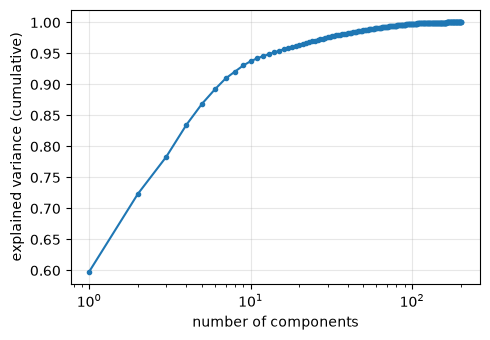

In [39]:
# ============================================================
# RANDOM-FILTER APPROACH — CELL 3: PCA — HOW MANY DIMENSIONS DOES THE DATA HAVE?
# ============================================================
# PCA on all candidate patches of all traces (the image is the same for all).
# Features are standardized first, so no filter dominates just by its scale.

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

all_feats = np.concatenate([f.reshape(-1, f.shape[-1]) for f in rf_features.values()])

rf_scaler = StandardScaler().fit(all_feats)
rf_pca = PCA().fit(rf_scaler.transform(all_feats))

cum = np.cumsum(rf_pca.explained_variance_ratio_)
for level in [0.80, 0.90, 0.95, 0.99]:
    print(f"{level:.0%} of the variance needs {np.searchsorted(cum, level) + 1} components")

plt.figure(figsize=(5, 3.5))
plt.plot(np.arange(1, len(cum) + 1), cum, marker=".")
plt.xscale("log")
plt.xlabel("number of components")
plt.ylabel("explained variance (cumulative)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Every trace in PCA coordinates: (steps, 20, components)
rf_pcs = {t: rf_pca.transform(rf_scaler.transform(f.reshape(-1, f.shape[-1]))).reshape(f.shape[0], f.shape[1], -1)
          for t, f in rf_features.items()}

In [40]:
# ============================================================
# RANDOM-FILTER APPROACH — CELL 4: LEARN THE REWARD IN PCA SPACE
# ============================================================
# reward(patch) = w · (first k PCA coordinates of the patch)
# P(candidate wins) = softmax of the 20 rewards  (same likelihood as before)
# k (how many components) is chosen on the learning steps only:
# fit on steps 1-60, check on steps 61-80. The last 20 steps are tested once.

from scipy.optimize import minimize
from scipy.special import logsumexp

K_OPTIONS = [2, 5, 10, 20, 50]
L2 = 0.01        # small penalty that keeps w finite for perfectly strict agents


def fit_choice(X, W, l2=L2):
    # X: (steps, 20, k) features,  W: (steps,) winners  ->  weights w (k,)
    rows = np.arange(len(W))
    def objective(w):
        R = X @ w
        logp = R - logsumexp(R, axis=1, keepdims=True)
        P = np.exp(logp)
        G = -P
        G[rows, W] += 1
        loss = -logp[rows, W].sum() + 0.5 * l2 * w @ w
        grad = -np.einsum("sc,sck->k", G, X) + l2 * w
        return loss, grad
    return minimize(objective, np.zeros(X.shape[2]), jac=True, method="L-BFGS-B").x


def score(X, W, w):
    # accuracy and "explained" (0 = random guessing, 1 = every choice explained)
    R = X @ w
    logp = R - logsumexp(R, axis=1, keepdims=True)
    nll = -logp[np.arange(len(W)), W].mean()
    acc = np.mean(R.argmax(axis=1) == W)
    return acc, 1 - nll / np.log(X.shape[1])


rf_results = {}
rows = []

for t in traces:
    X_all, W = rf_pcs[t], rf_data[t][1]
    fit, val, disc, lock = slice(0, N_FIT), slice(N_FIT, N_DISCOVER), slice(0, N_DISCOVER), slice(N_DISCOVER, None)

    # choose k on the validation steps (61-80)
    val_explained = {}
    for k in K_OPTIONS:
        w = fit_choice(X_all[fit, :, :k], W[fit])
        val_explained[k] = score(X_all[val, :, :k], W[val], w)[1]
    k_best = max(val_explained, key=val_explained.get)

    # final model on all 80 learning steps, tested once on the locked steps
    w = fit_choice(X_all[disc, :, :k_best], W[disc])
    acc_lock, ex_lock = score(X_all[lock, :, :k_best], W[lock], w)
    acc_learn, _ = score(X_all[disc, :, :k_best], W[disc], w)

    rf_results[t] = {"k": k_best, "w": w}
    rows.append({"trace": rf_names[t], "components": k_best,
                 "accuracy (learning)": acc_learn,
                 "accuracy (LOCKED)": acc_lock, "explained (LOCKED)": ex_lock})

rf_table = pd.DataFrame(rows).set_index("trace")
print(rf_table.round(2).to_string())
print("\nRandom guessing: accuracy 5%, explained 0. LOCKED = 20 unseen steps (one step = 5%).")

       components  accuracy (learning)  accuracy (LOCKED)  explained (LOCKED)
trace                                                                        
gpt0            5                 0.29               0.35                0.16
gpt1            2                 0.18               0.05                0.05
gpt2           10                 0.51               0.45                0.41
sim0           50                 1.00               0.75                0.43
sim1           10                 0.79               0.75                0.55
sim2           10                 0.90               0.90                0.77
sim3           10                 0.22               0.15                0.07
sim4            5                 0.86               0.65                0.73
sim5            5                 0.82               0.70                0.84
sim6           10                 0.50               0.55                0.57
sim7           50                 0.57               0.50       

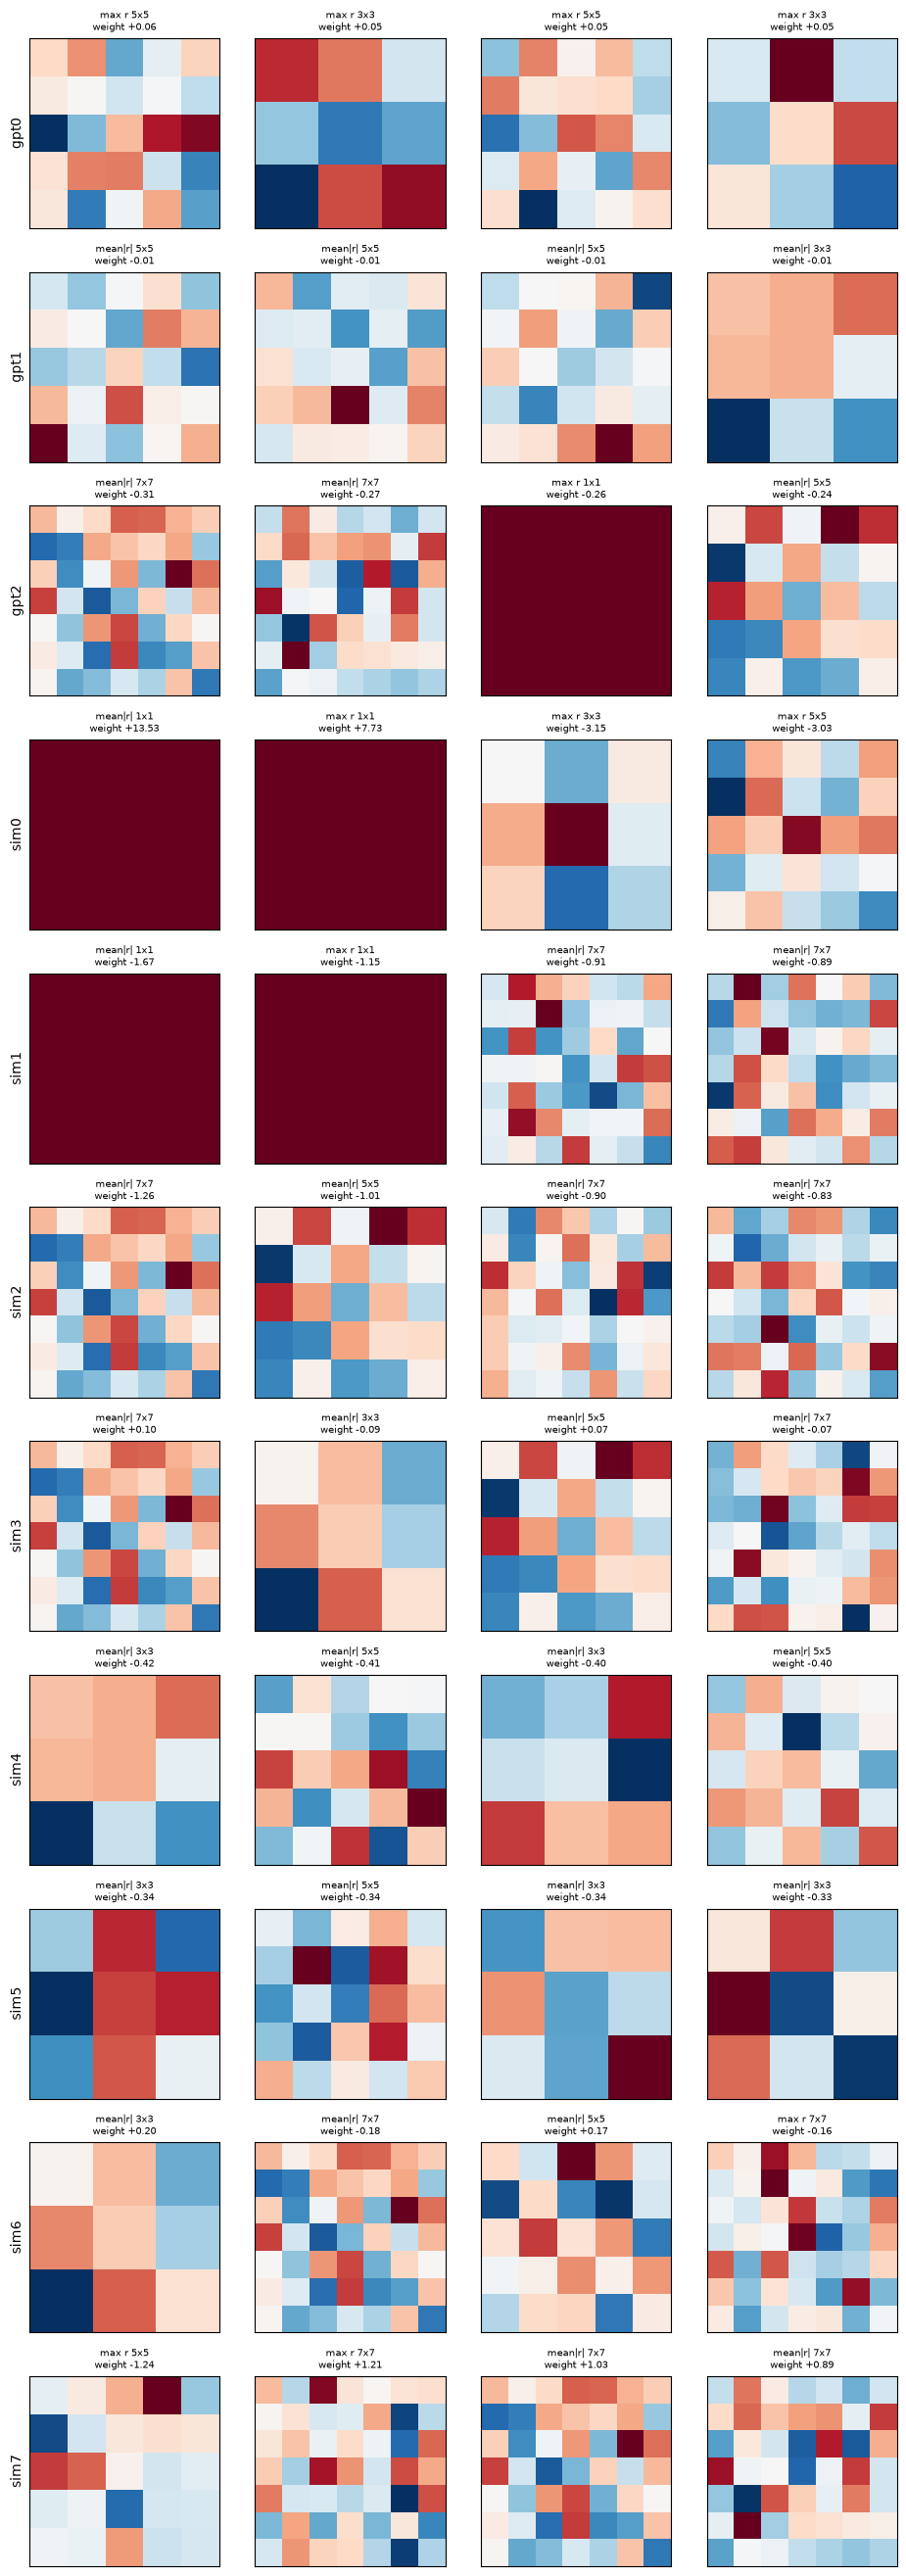

In [43]:
# ============================================================
# RANDOM-FILTER APPROACH — CELL 5: WHICH FILTERS DRIVE EACH AGENT?
# ============================================================
# The reward is linear in PCA space, so it can be mapped back to the
# original features:  weight per feature = PCA directions · w / feature scale.
# Then we show the 4 most important filters of every trace.

def feature_weights(t):
    # Weight of every (filter, mean/max) feature, in standardized units:
    # "how much the reward changes when this feature changes by one standard deviation".
    # This makes features with different scales comparable.
    k, w = rf_results[t]["k"], rf_results[t]["w"]
    return rf_pca.components_[:k].T @ w

def get_filter(name):
    # name like "max r 5x5 #12" -> the 2D filter
    size = int(name.split()[-2].split("x")[0])
    idx = int(name.split("#")[1])
    return random_filters[size][idx, 0].numpy()

N_TOP = 4
fig, axes = plt.subplots(len(traces), N_TOP, figsize=(2.4 * N_TOP, 2.4 * len(traces)), squeeze=False)

for row, t in enumerate(traces):
    wf = feature_weights(t)
    top = np.argsort(-np.abs(wf))[:N_TOP]
    for col, j in enumerate(top):
        ax = axes[row, col]
        f = get_filter(feature_names[j])
        lim = np.abs(f).max()
        ax.imshow(f, cmap="RdBu_r", vmin=-lim, vmax=lim)
        ax.set_title(f"{feature_names[j].split(' #')[0]}\nweight {wf[j]:+.2f}", fontsize=7)
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(rf_names[t])

plt.tight_layout()
plt.show()

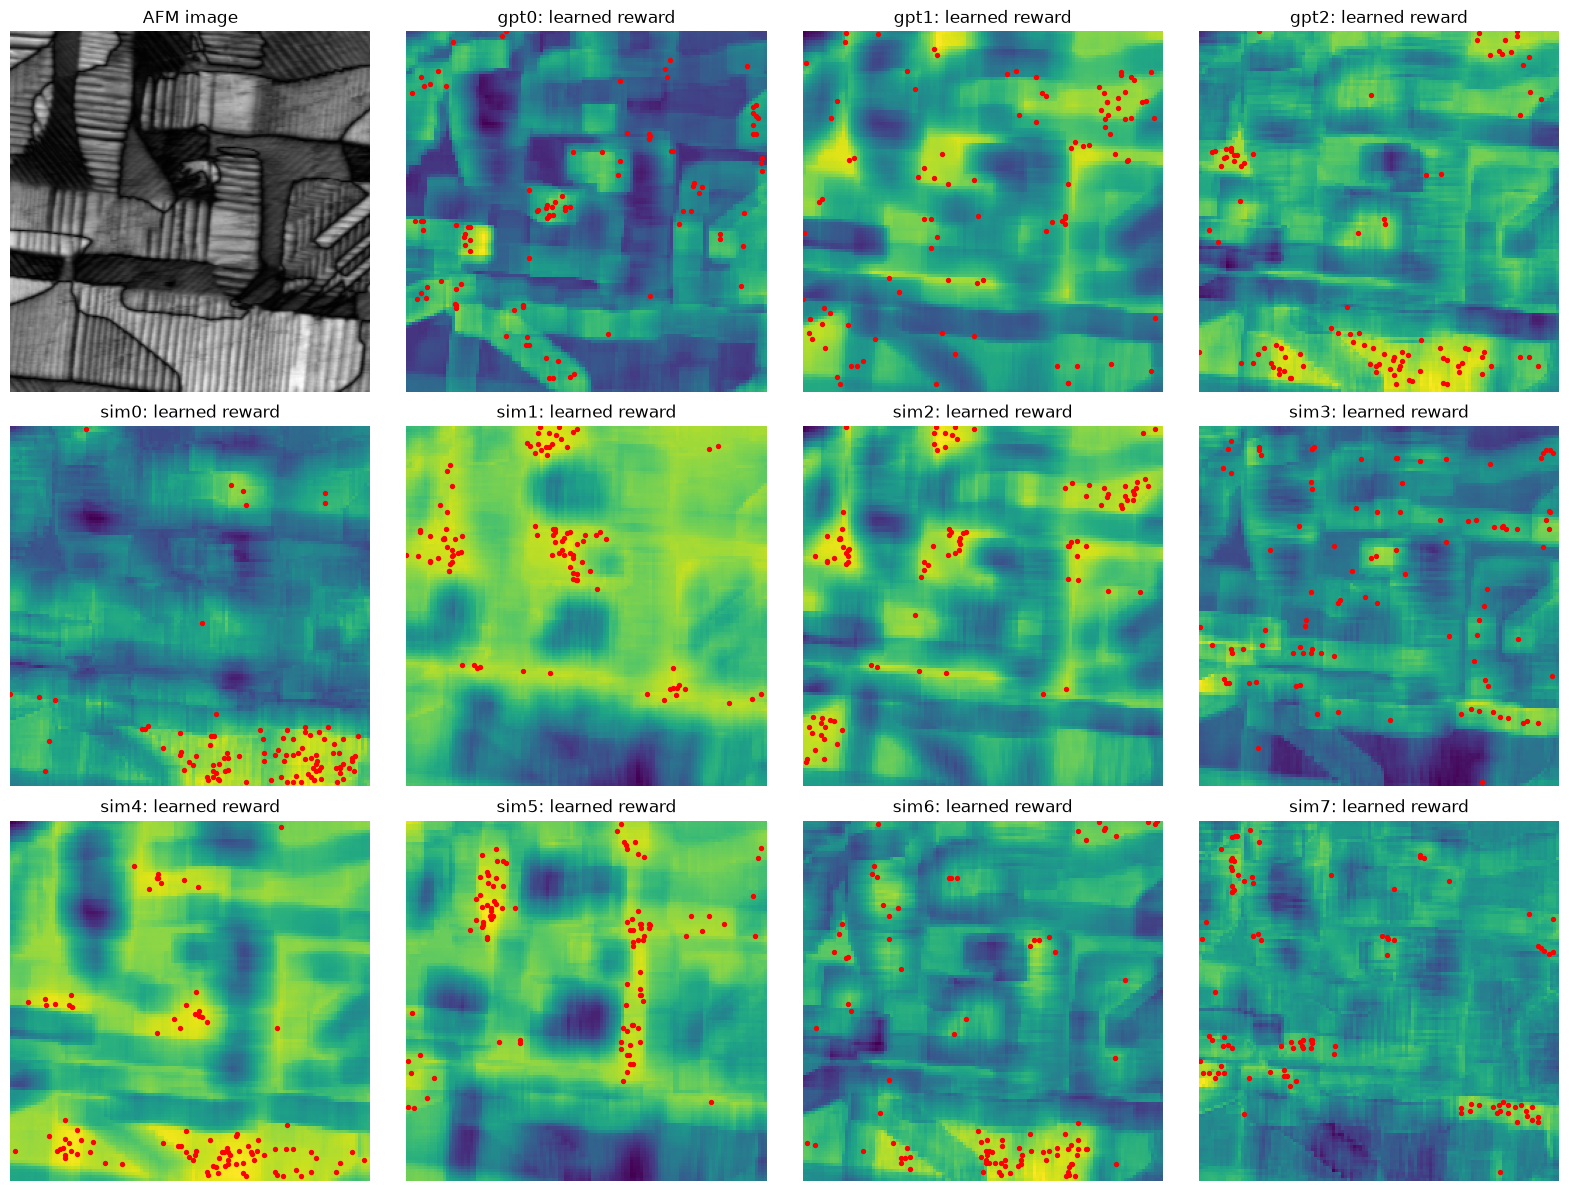

In [44]:
# ============================================================
# RANDOM-FILTER APPROACH — CELL 6: REWARD MAPS OVER THE WHOLE IMAGE
# ============================================================
# Every learned reward applied to crops of the whole AFM image
# (every 2nd pixel, to keep it fast). Red dots = the agent's real choices.

from numpy.lib.stride_tricks import sliding_window_view

PATCH_SIZE = rf_data[0][0].shape[-1]
half_p = PATCH_SIZE // 2
STEP_PX = 2

win = sliding_window_view(img.astype(np.float32), (PATCH_SIZE, PATCH_SIZE))[::STEP_PX, ::STEP_PX]
mr, mc = win.shape[:2]
map_pcs = rf_pca.transform(rf_scaler.transform(patch_features(win.reshape(-1, PATCH_SIZE, PATCH_SIZE))))

n_panels = len(traces) + 1
ncols = 4
nrows = int(np.ceil(n_panels / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.ravel()
axes[0].imshow(img, cmap="gray")
axes[0].set_title("AFM image")
extent = [half_p, half_p + mc * STEP_PX, half_p + mr * STEP_PX, half_p]

for ax, t in zip(axes[1:], traces):
    k, w = rf_results[t]["k"], rf_results[t]["w"]
    xy = np.array([traces[t][s]["position"] for s in sorted(traces[t])])
    ax.imshow((map_pcs[:, :k] @ w).reshape(mr, mc), cmap="viridis", extent=extent)
    ax.scatter(xy[:, 0], xy[:, 1], s=8, c="red")
    ax.set_title(f"{rf_names[t]}: learned reward")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [46]:
# ============================================================
# RANDOM-FILTER APPROACH — CELL 7: ADD SIMPLE STATISTICAL MEASURES
# ============================================================
# Statistics are kept OUTSIDE the PCA, as their own columns, so a simple
# rule like "brightest patch" is one clear feature and is not diluted
# among 200 filter features.
# Model: reward = w_stats · (statistics) + w_pcs · (first k PCA coordinates)

from scipy.stats import skew, kurtosis

def patch_stats(patches):
    # patches: (N, 20, 20) -> table of simple statistics (N, n_stats)
    p = patches.reshape(len(patches), -1).astype(float)
    gy, gx = np.gradient(patches.astype(float), axis=(1, 2))
    grad = np.sqrt(gx ** 2 + gy ** 2).reshape(len(patches), -1)
    return np.column_stack([
        p.mean(1), p.std(1), p.min(1), p.max(1),                 # brightness and contrast
        np.percentile(p, 10, axis=1), np.percentile(p, 90, axis=1),
        skew(p, axis=1), kurtosis(p, axis=1),                    # shape of the histogram
        grad.mean(1), grad.max(1),                               # edges
    ])

stat_names = ["mean", "std", "min", "max", "p10", "p90", "skew", "kurtosis", "grad mean", "grad max"]

rf_stats = {}
for t, (P, W) in rf_data.items():
    S, C = P.shape[:2]
    rf_stats[t] = patch_stats(P.reshape(S * C, *P.shape[2:])).reshape(S, C, -1)

# Standardize the statistics with all patches of all traces
all_stats = np.concatenate([s.reshape(-1, s.shape[-1]) for s in rf_stats.values()])
stat_scaler = StandardScaler().fit(all_stats)
rf_stats_s = {t: stat_scaler.transform(s.reshape(-1, s.shape[-1])).reshape(s.shape) for t, s in rf_stats.items()}

N_STATS = len(stat_names)
K_OPTIONS_COMBINED = [0, 2, 5, 10, 20, 50]     # 0 = statistics only

combined_results = {}
rows = []

for t in traces:
    W = rf_data[t][1]
    fit, val, disc, lock = slice(0, N_FIT), slice(N_FIT, N_DISCOVER), slice(0, N_DISCOVER), slice(N_DISCOVER, None)

    def X(k):
        # statistics + first k PCA coordinates: (steps, 20, N_STATS + k)
        return np.concatenate([rf_stats_s[t], rf_pcs[t][:, :, :k]], axis=2)

    # choose k on the validation steps (61-80)
    val_explained = {}
    for k in K_OPTIONS_COMBINED:
        w = fit_choice(X(k)[fit], W[fit])
        val_explained[k] = score(X(k)[val], W[val], w)[1]
    k_best = max(val_explained, key=val_explained.get)

    # final model on all 80 learning steps, tested once on the locked steps
    w = fit_choice(X(k_best)[disc], W[disc])
    acc_lock, ex_lock = score(X(k_best)[lock], W[lock], w)

    combined_results[t] = {"k": k_best, "w": w}
    top_stat = stat_names[np.argmax(np.abs(w[:N_STATS]))]
    rows.append({"trace": rf_names[t],
                 "filters only (LOCKED acc)": rf_table.loc[rf_names[t], "accuracy (LOCKED)"],
                 "stats + filters (LOCKED acc)": acc_lock,
                 "explained (LOCKED)": ex_lock,
                 "PCs used": k_best,
                 "strongest statistic": f"{top_stat} ({w[stat_names.index(top_stat)]:+.1f})"})

combined_table = pd.DataFrame(rows).set_index("trace")
print(combined_table.round(2).to_string())
print("\nWeights of the statistics are in standardized units (per 1 std of that statistic).")

       filters only (LOCKED acc)  stats + filters (LOCKED acc)  explained (LOCKED)  PCs used strongest statistic
trace                                                                                                           
gpt0                        0.35                          0.40                0.17         5          std (-1.2)
gpt1                        0.05                          0.25                0.28        10    grad mean (-3.7)
gpt2                        0.45                          0.30                0.05         2    grad mean (+3.6)
sim0                        0.75                          0.95                0.96         0        mean (+20.5)
sim1                        0.75                          0.80                0.55         5        mean (-14.3)
sim2                        0.90                          0.90                0.93         0         std (-18.1)
sim3                        0.15                          0.20                0.25        20   g

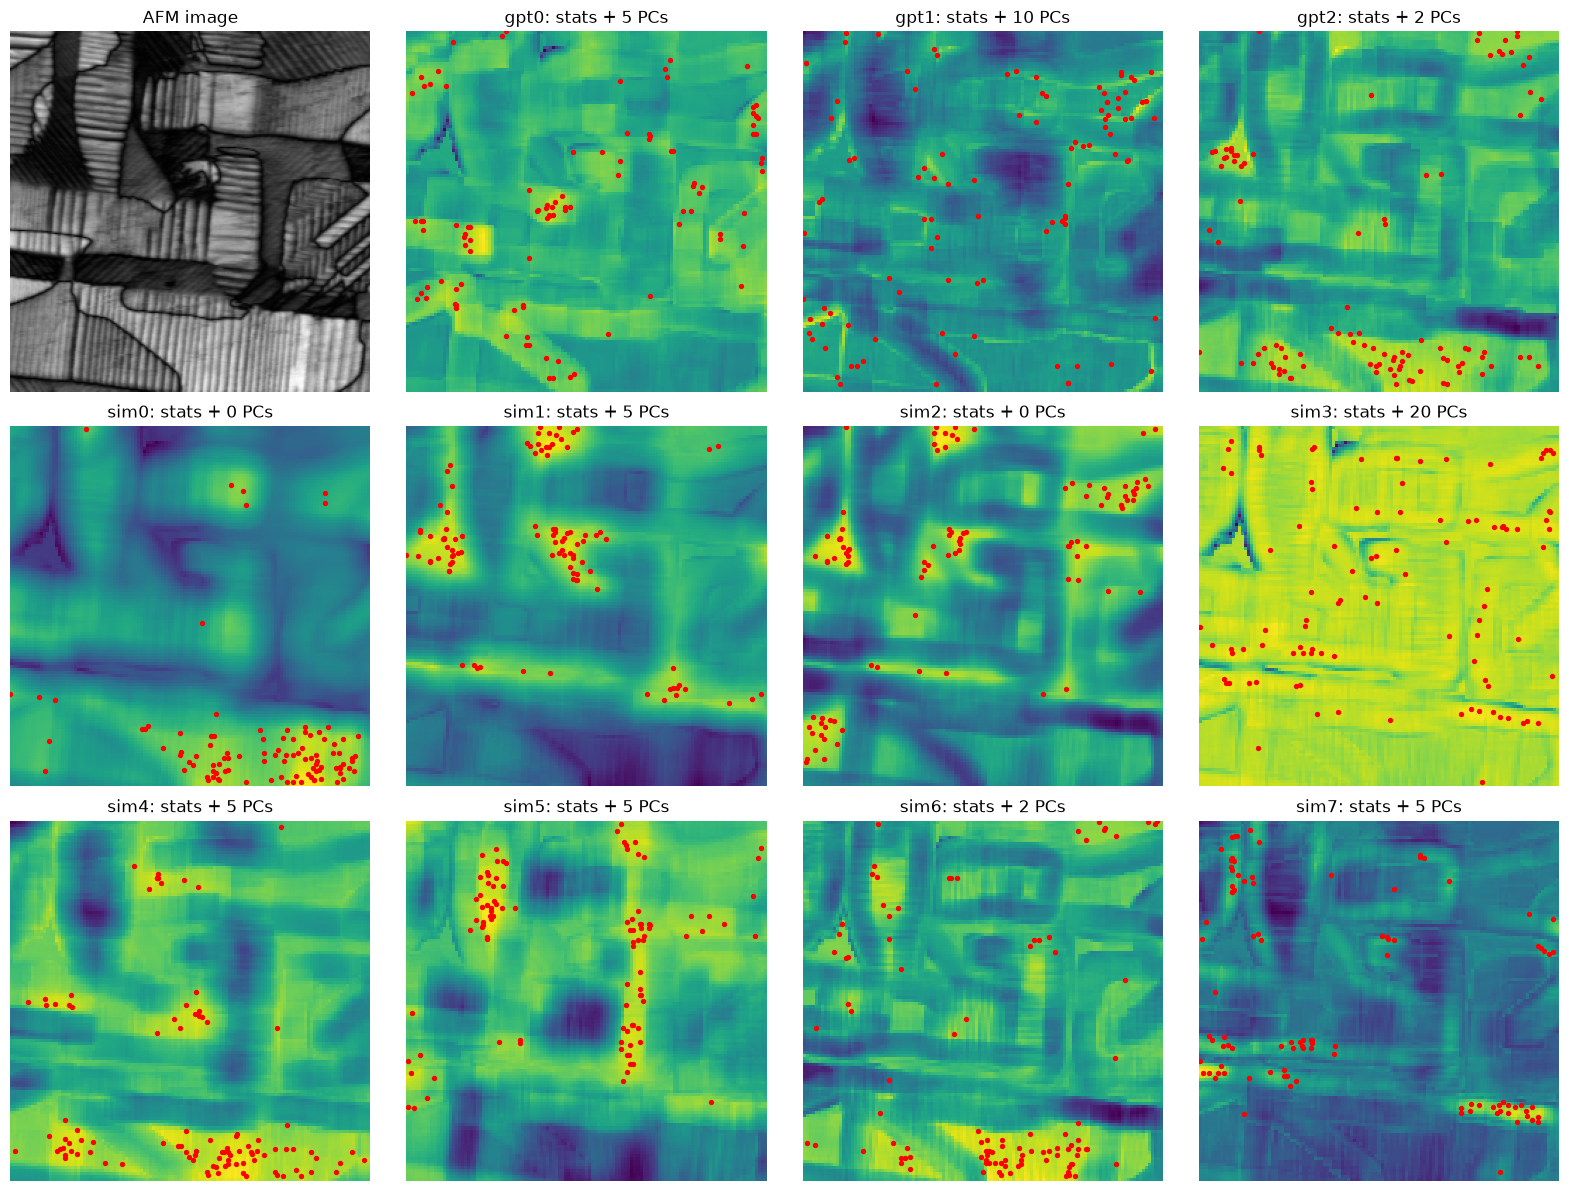

In [48]:
# ============================================================
# RANDOM-FILTER APPROACH — CELL 8: REWARD MAPS (STATISTICS + FILTERS)
# ============================================================
# The combined reward from cell 7 applied to crops of the whole AFM image.
# Reuses from cell 6: win (image crops), map_pcs (their PCA coordinates),
# mr, mc, extent. Red dots = the agent's real choices.

# Statistics of every map crop, standardized like the training patches
map_stats_s = stat_scaler.transform(patch_stats(win.reshape(-1, PATCH_SIZE, PATCH_SIZE)))

n_panels = len(traces) + 1
ncols = 4
nrows = int(np.ceil(n_panels / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.ravel()
axes[0].imshow(img, cmap="gray")
axes[0].set_title("AFM image")

for ax, t in zip(axes[1:], traces):
    k, w = combined_results[t]["k"], combined_results[t]["w"]

    # same columns as in cell 7: statistics first, then the first k PCA coordinates
    X_map = np.concatenate([map_stats_s, map_pcs[:, :k]], axis=1)
    reward = (X_map @ w).reshape(mr, mc)

    xy = np.array([traces[t][s]["position"] for s in sorted(traces[t])])
    ax.imshow(reward, cmap="viridis", extent=extent)
    ax.scatter(xy[:, 0], xy[:, 1], s=8, c="red")
    ax.set_title(f"{rf_names[t]}: stats + {k} PCs")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [28]:
def reward(patch):

    p = patch.astype(float)

    # --------------------------------------------------------
    # YOUR HYPOTHESIS HERE
    # --------------------------------------------------------

    score = np.mean(p)   # example only — modify this

    return score


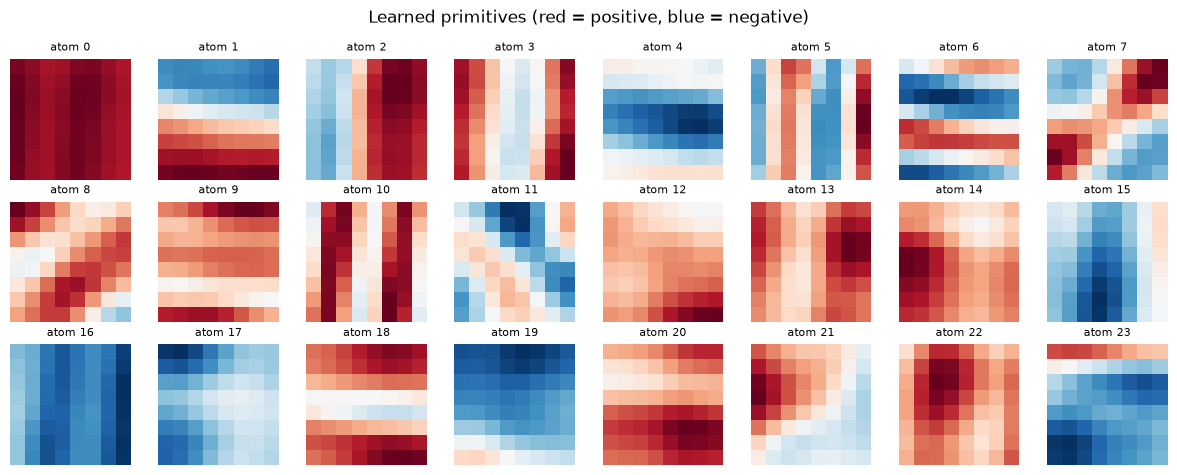

In [11]:
# ============================================================
# PRIMITIVES APPROACH — CELL 1: LEARN THE PRIMITIVES FROM THE IMAGE
# ============================================================
# Idea: every small 8x8 piece of the image is written as a sum of a few
# basic shapes ("atoms" / primitives):
#     piece  ≈  c1 * atom_a  +  c2 * atom_b  +  c3 * atom_c
# The atoms are LEARNED from the image itself (sparse dictionary learning).
# Needs only: traces, trace_files, img

import os
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.decomposition import MiniBatchDictionaryLearning
from sklearn.feature_extraction.image import reconstruct_from_patches_2d

ATOM_SIZE = 8        # size of one primitive (pixels)
N_ATOMS = 24         # how many primitives in the vocabulary
N_NONZERO = 3        # how many primitives may be used for one 8x8 piece

img32 = img.astype(np.float32)

# All 8x8 pieces of the image (moving 1 pixel at a time)
pieces = sliding_window_view(img32, (ATOM_SIZE, ATOM_SIZE))
p_rows, p_cols = pieces.shape[:2]
pieces = pieces.reshape(-1, ATOM_SIZE * ATOM_SIZE)

# Learn the dictionary on a random subset (faster, same result)
dl_rng = np.random.default_rng(0)
train_idx = dl_rng.choice(len(pieces), 20000, replace=False)

dico = MiniBatchDictionaryLearning(
    n_components=N_ATOMS,
    alpha=0.1,                         # sparsity during learning
    batch_size=256,
    max_iter=50,
    transform_algorithm="omp",         # coding: pick the best few atoms
    transform_n_nonzero_coefs=N_NONZERO,
    random_state=0,
)
dico.fit(pieces[train_idx])
atoms = dico.components_.reshape(N_ATOMS, ATOM_SIZE, ATOM_SIZE)

# Show the learned primitives
fig, axes = plt.subplots(3, 8, figsize=(12, 4.8))
for k, ax in enumerate(axes.ravel()):
    lim = np.abs(atoms[k]).max()
    ax.imshow(atoms[k], cmap="RdBu_r", vmin=-lim, vmax=lim)
    ax.set_title(f"atom {k}", fontsize=8)
    ax.axis("off")
plt.suptitle("Learned primitives (red = positive, blue = negative)")
plt.tight_layout()
plt.show()

Reconstruction error: 16.4% of the image contrast


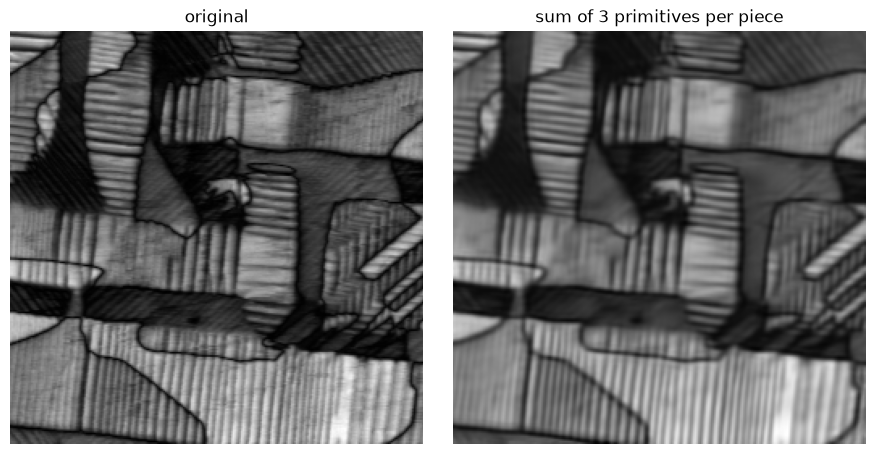

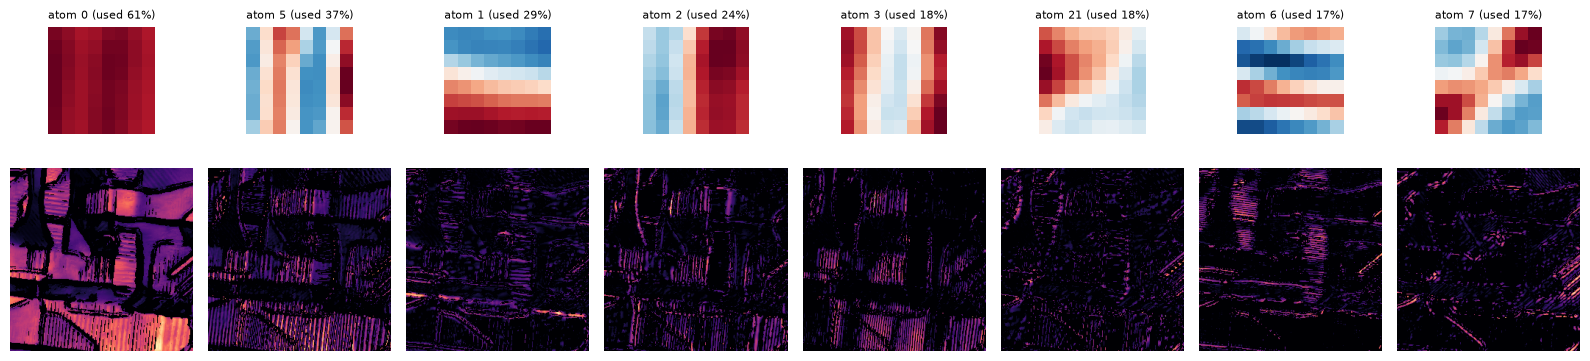

In [12]:
# ============================================================
# PRIMITIVES APPROACH — CELL 2: WRITE THE WHOLE IMAGE AS A SUM OF PRIMITIVES
# ============================================================
# Every 8x8 piece gets its few coefficients (codes).
# From the codes we (1) rebuild the image to check the primitives are enough,
# and (2) make an "activation map" per primitive: where and how strongly it is used.

codes = dico.transform(pieces)                         # (number of pieces, N_ATOMS), mostly zeros
rebuilt_pieces = codes @ dico.components_
rebuilt = reconstruct_from_patches_2d(rebuilt_pieces.reshape(-1, ATOM_SIZE, ATOM_SIZE), img32.shape)

error = np.sqrt(np.mean((rebuilt - img32) ** 2)) / img32.std()
print(f"Reconstruction error: {error:.1%} of the image contrast")

# Activation map of every primitive: |code| at every piece position
activation = np.abs(codes).reshape(p_rows, p_cols, N_ATOMS)

# How often each primitive is used (fraction of pieces)
usage = (codes != 0).mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(img32, cmap="gray"); axes[0].set_title("original")
axes[1].imshow(rebuilt, cmap="gray"); axes[1].set_title(f"sum of {N_NONZERO} primitives per piece")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Where the 8 most used primitives sit in the image
top_used = np.argsort(-usage)[:8]
fig, axes = plt.subplots(2, 8, figsize=(16, 4.4), gridspec_kw={"height_ratios": [1, 3]})
for i, k in enumerate(top_used):
    lim = np.abs(atoms[k]).max()
    axes[0, i].imshow(atoms[k], cmap="RdBu_r", vmin=-lim, vmax=lim)
    axes[0, i].set_title(f"atom {k} (used {usage[k]:.0%})", fontsize=8)
    axes[1, i].imshow(activation[:, :, k], cmap="magma")
    for ax in axes[:, i]:
        ax.axis("off")
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# PRIMITIVES APPROACH — CELL 3: EVERY CANDIDATE PATCH AS A "BAG OF PRIMITIVES"
# ============================================================
# For a 20x20 candidate: average activation of each primitive inside it.
#   -> N_ATOMS numbers per candidate: "how much of each primitive it contains"
# Computed once for every 20x20 crop of the image, then looked up per candidate.

from scipy.ndimage import uniform_filter

PATCH = traces[0][0]["patches"][0].shape[0]          # 20
inner = PATCH - ATOM_SIZE + 1                         # 13 piece positions per side inside a crop

# Average of each activation map over every 13x13 block = over every 20x20 crop
crop_bag = np.stack([
    uniform_filter(activation[:, :, k], size=inner, mode="constant")
    [inner // 2: inner // 2 + img32.shape[0] - PATCH + 1,
     inner // 2: inner // 2 + img32.shape[1] - PATCH + 1]
    for k in range(N_ATOMS)
], axis=-1)                                           # (237, 237, N_ATOMS)
crop_rows, crop_cols = crop_bag.shape[:2]

# Find each candidate's location in the image (exact pixel match)
crops = sliding_window_view(img32, (PATCH, PATCH))
lookup = {crops[r, c].tobytes(): (r, c) for r in range(crop_rows) for c in range(crop_cols)}

dl_names = {t: os.path.splitext(os.path.basename(trace_files[t]))[0]
                 .replace("gpt_decision_trace_", "gpt").replace("simulated_decision_trace_", "sim")
            for t in traces}

dl_data = {}
for t, trace in traces.items():
    steps = sorted(trace.keys())
    X, W = [], []
    for s in steps:
        rc = [lookup[np.ascontiguousarray(p, dtype=np.float32).tobytes()] for p in trace[s]["patches"]]
        X.append([crop_bag[r, c] for r, c in rc])
        W.append(trace[s]["selected_candidate"])
    dl_data[t] = (np.array(X), np.array(W))           # (steps, 20, N_ATOMS), (steps,)

# Standardize the bag features (same scale for all traces)
bag_mean = crop_bag.reshape(-1, N_ATOMS).mean(axis=0)
bag_std = crop_bag.reshape(-1, N_ATOMS).std(axis=0)
dl_data = {t: ((X - bag_mean) / bag_std, W) for t, (X, W) in dl_data.items()}

print("Candidates per trace:", dl_data[0][0].shape, "(steps, candidates, primitives)")

Candidates per trace: (100, 20, 24) (steps, candidates, primitives)


       accuracy (LOCKED)  explained (LOCKED)                top primitives
trace                                                                     
gpt0                0.20                0.12    10(-1.1), 5(-0.9), 0(+0.9)
gpt1                0.30                0.13   11(-1.7), 6(-1.3), 12(-0.9)
gpt2                0.45                0.16    9(-3.6), 8(-3.1), 12(-1.9)
sim0                0.95                0.92   0(+20.9), 18(+7.4), 6(-5.0)
sim1                0.80                0.90  0(-16.1), 6(-11.0), 5(-10.8)
sim2                0.85                0.81    6(-7.3), 1(-5.0), 13(-3.8)
sim3                0.35                0.32  23(+0.5), 10(-0.5), 19(+0.5)
sim4                0.60                0.72    19(-7.7), 6(-3.8), 7(-3.6)
sim5                0.65                0.54  3(-11.3), 22(-3.2), 16(-2.8)
sim6                0.55                0.48     7(-2.1), 8(-1.8), 2(-1.4)
sim7                0.50                0.44   0(-2.1), 22(-1.3), 16(-1.2)

Random guessing: accurac

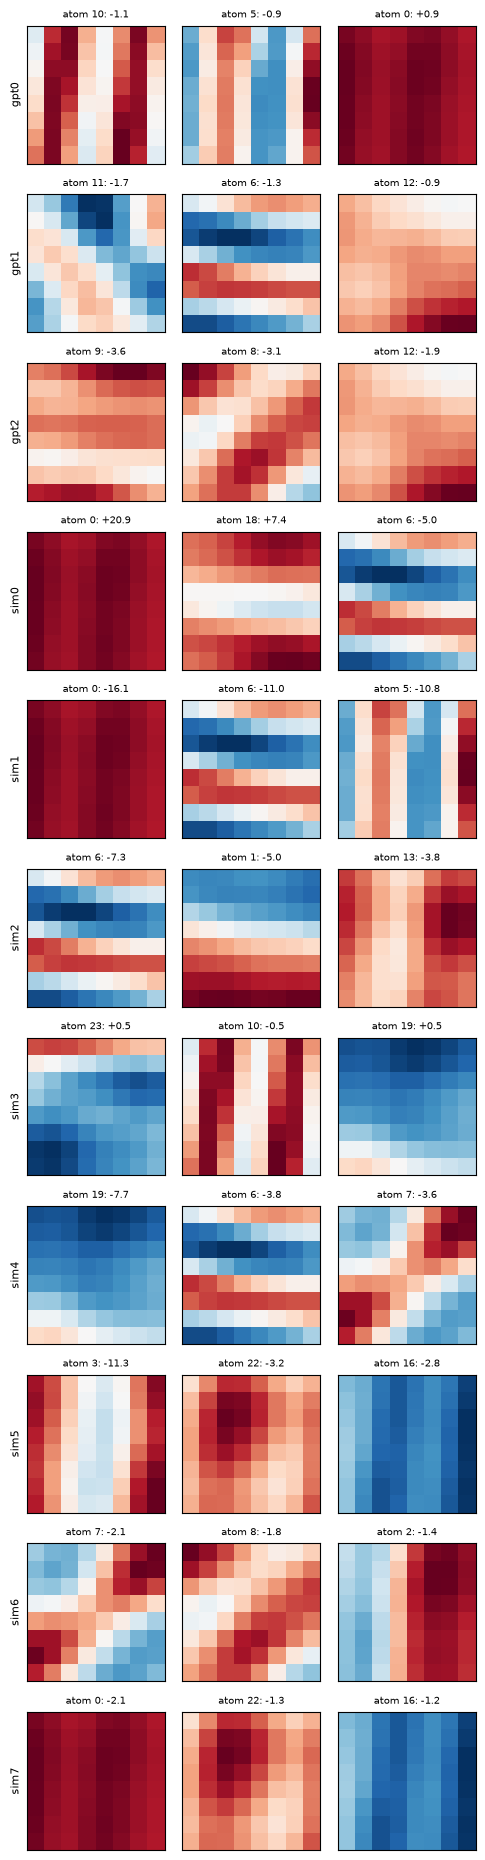

In [14]:
# ============================================================
# PRIMITIVES APPROACH — CELL 4: WHICH PRIMITIVES DOES EACH AGENT WANT?
# ============================================================
# reward(patch) = w · (amount of each primitive)      -> one weight per primitive
# fitted with the softmax choice likelihood on the first 80 steps,
# tested once on the last 20 (locked) steps.

from scipy.optimize import minimize
from scipy.special import logsumexp

def fit_choice(X, W, l2=0.01):
    rows = np.arange(len(W))
    def objective(w):
        R = X @ w
        logp = R - logsumexp(R, axis=1, keepdims=True)
        G = -np.exp(logp)
        G[rows, W] += 1
        return -logp[rows, W].sum() + 0.5 * l2 * w @ w, -np.einsum("sc,sck->k", G, X) + l2 * w
    return minimize(objective, np.zeros(X.shape[2]), jac=True, method="L-BFGS-B").x

def score(X, W, w):
    R = X @ w
    logp = R - logsumexp(R, axis=1, keepdims=True)
    acc = np.mean(R.argmax(axis=1) == W)
    explained = 1 - (-logp[np.arange(len(W)), W].mean()) / np.log(X.shape[1])
    return acc, explained

disc, lock = slice(0, 80), slice(80, None)
dl_weights = {}
rows = []
for t, (X, W) in dl_data.items():
    w = fit_choice(X[disc], W[disc])
    dl_weights[t] = w
    acc, ex = score(X[lock], W[lock], w)
    top = np.argsort(-np.abs(w))[:3]
    rows.append({"trace": dl_names[t], "accuracy (LOCKED)": acc, "explained (LOCKED)": ex,
                 "top primitives": ", ".join(f"{k}({w[k]:+.1f})" for k in top)})

dl_table = pd.DataFrame(rows).set_index("trace")
print(dl_table.round(2).to_string())
print("\nRandom guessing: accuracy 5%. + = agent wants more of this primitive, - = less.")

# The 3 most important primitives of every trace, as images
fig, axes = plt.subplots(len(dl_data), 3, figsize=(5, 1.7 * len(dl_data)), squeeze=False)
for row, t in enumerate(dl_data):
    w = dl_weights[t]
    for col, k in enumerate(np.argsort(-np.abs(w))[:3]):
        ax = axes[row, col]
        lim = np.abs(atoms[k]).max()
        ax.imshow(atoms[k], cmap="RdBu_r", vmin=-lim, vmax=lim)
        ax.set_title(f"atom {k}: {w[k]:+.1f}", fontsize=7)
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(dl_names[t], fontsize=8)
plt.tight_layout()
plt.show()

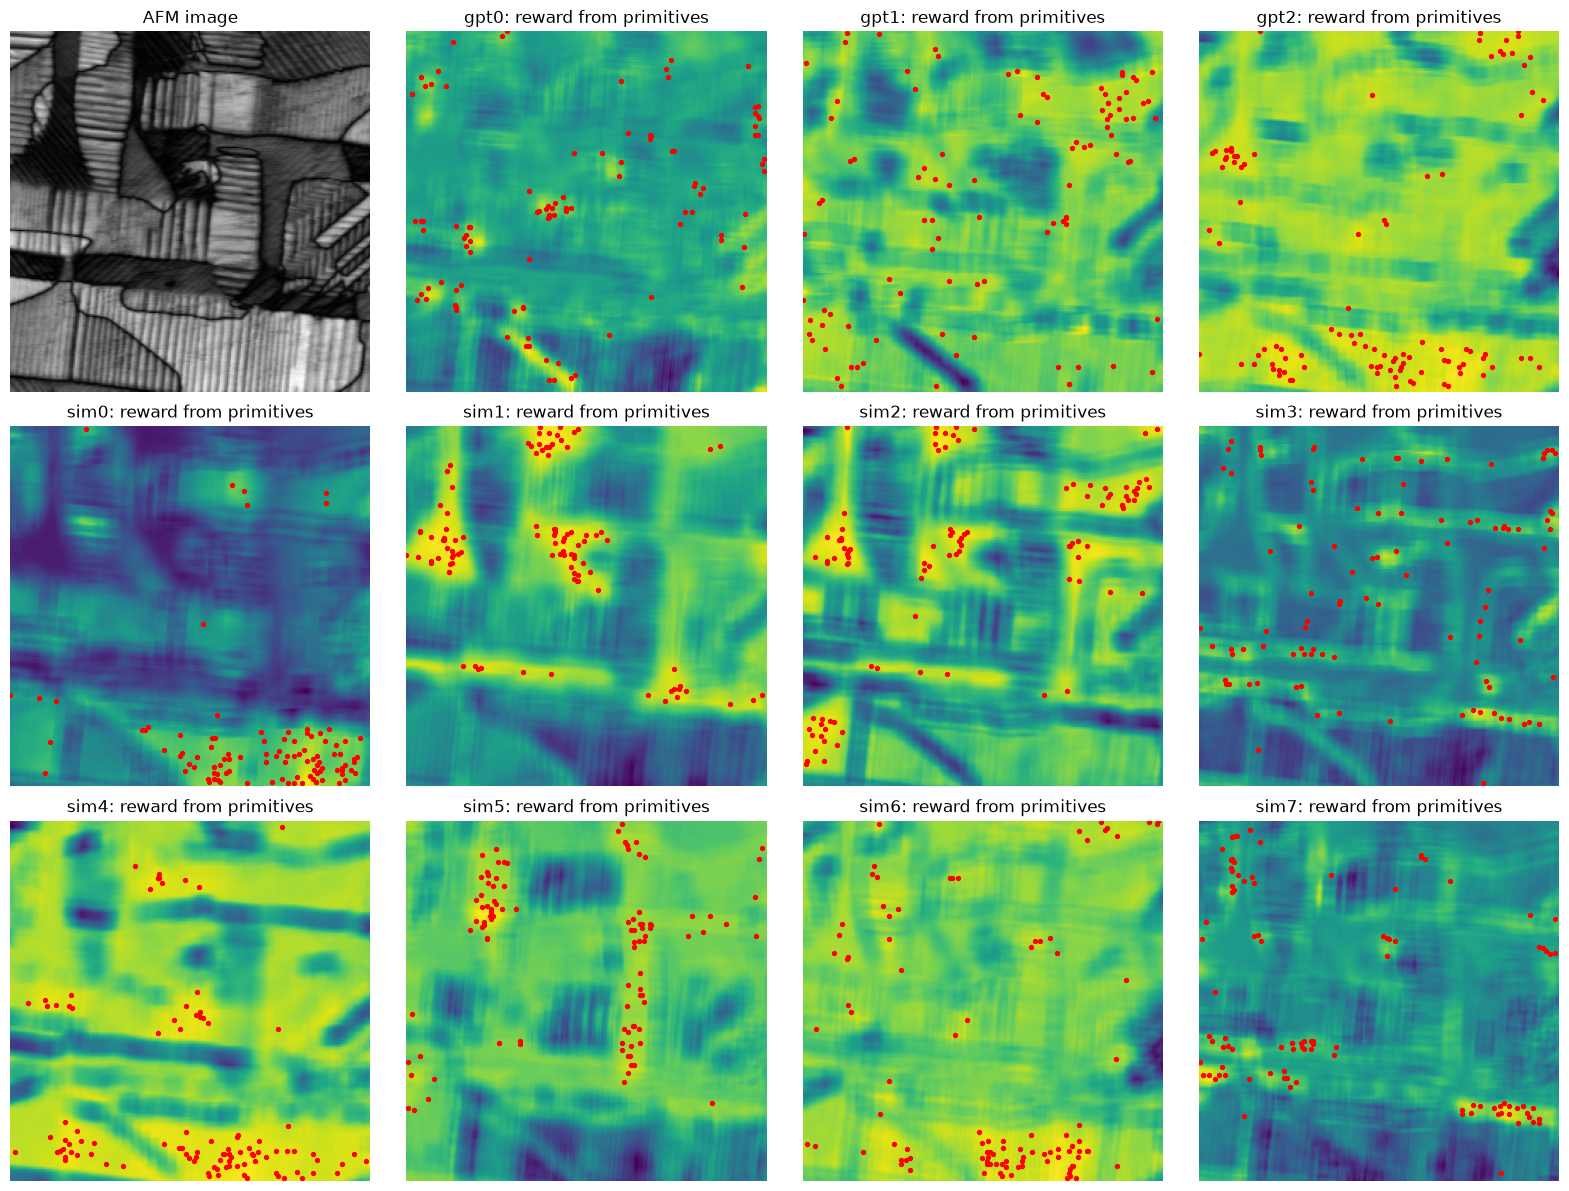

In [15]:
# ============================================================
# PRIMITIVES APPROACH — CELL 5: REWARD MAPS
# ============================================================
# Reward of every 20x20 crop of the image = w · (its bag of primitives).
# Red dots = the agent's real choices.

half = PATCH // 2
extent = [half, half + crop_cols, half + crop_rows, half]
bag_s = (crop_bag - bag_mean) / bag_std

n_panels = len(dl_data) + 1
ncols = 4
nrows = int(np.ceil(n_panels / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.ravel()
axes[0].imshow(img32, cmap="gray")
axes[0].set_title("AFM image")

for ax, t in zip(axes[1:], dl_data):
    xy = np.array([traces[t][s]["position"] for s in sorted(traces[t])])
    ax.imshow(bag_s @ dl_weights[t], cmap="viridis", extent=extent)
    ax.scatter(xy[:, 0], xy[:, 1], s=8, c="red")
    ax.set_title(f"{dl_names[t]}: reward from primitives")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### SCORE ALL PATCHES IN ONE STEP

In [29]:
TRACE_ID = 6
STEP = 1

trace = traces[TRACE_ID]
step_data = trace[STEP - 1]

patches = step_data["patches"]
actual_selected = step_data["selected_candidate"]


# Score all 20 candidates
scores = np.array([
    reward(patch)
    for patch in patches
])


# Select highest-scoring candidate
predicted_selected = int(
    np.argmax(scores)
)

print(
    f"Actual selection:    Candidate {actual_selected}"
)

print(
    f"Predicted selection: Candidate {predicted_selected}"
)

Actual selection:    Candidate 16
Predicted selection: Candidate 18



### VISUALIZE PREDICTED vs ACTUAL CLEARLY

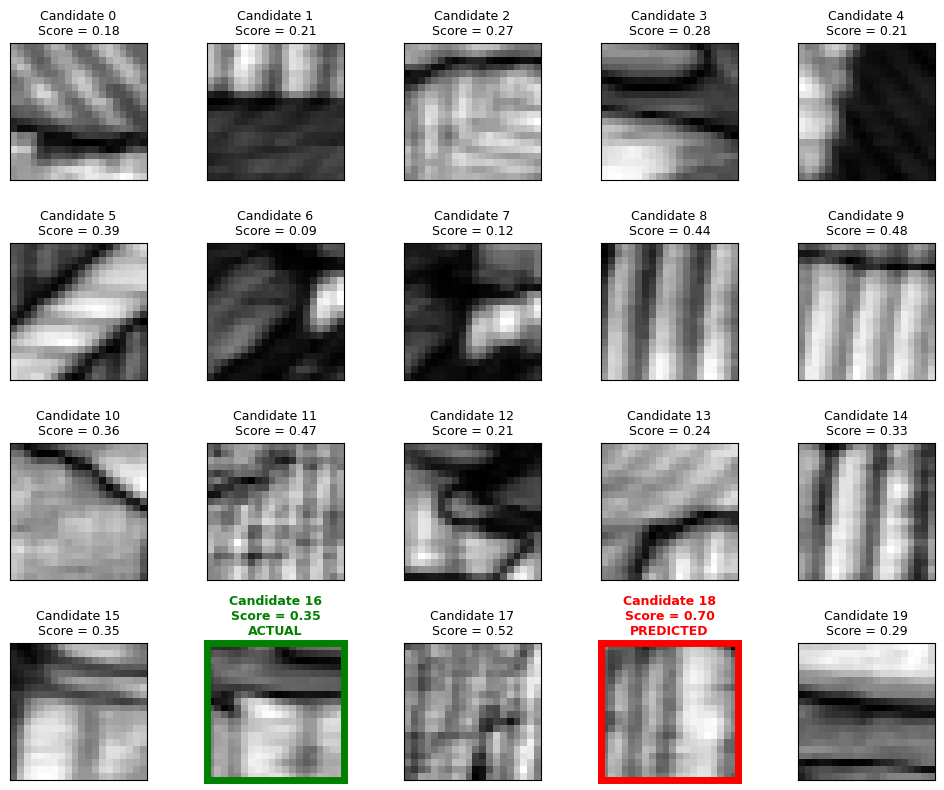

In [30]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(10, 8)
)

for i, ax in enumerate(axes.flat):

    ax.imshow(
        patches[i],
        cmap="gray"
    )

    ax.set_title(
        f"Candidate {i}\nScore = {scores[i]:.2f}",
        fontsize=9
    )

    # --------------------------------------------------------
    # Highlight selections
    # --------------------------------------------------------

    if i == actual_selected and i == predicted_selected:

        for spine in ax.spines.values():
            spine.set_edgecolor("blue")
            spine.set_linewidth(5)

        ax.set_title(
            f"Candidate {i}\n"
            f"Score = {scores[i]:.2f}\n"
            f"ACTUAL + PREDICTED",
            fontsize=9,
            color="blue",
            weight="bold"
        )

    elif i == actual_selected:

        for spine in ax.spines.values():
            spine.set_edgecolor("green")
            spine.set_linewidth(5)

        ax.set_title(
            f"Candidate {i}\n"
            f"Score = {scores[i]:.2f}\n"
            f"ACTUAL",
            fontsize=9,
            color="green",
            weight="bold"
        )

    elif i == predicted_selected:

        for spine in ax.spines.values():
            spine.set_edgecolor("red")
            spine.set_linewidth(5)

        ax.set_title(
            f"Candidate {i}\n"
            f"Score = {scores[i]:.2f}\n"
            f"PREDICTED",
            fontsize=9,
            color="red",
            weight="bold"
        )

    ax.set_xticks([])
    ax.set_yticks([])


plt.tight_layout()
plt.show()

### BENCHMARK HYPOTHESIZED REWARD ACROSS ALL STEPS

In [31]:
results = []

for step in sorted(trace.keys()):

    step_data = trace[step]

    patches = step_data["patches"]
    actual_selected = step_data["selected_candidate"]

    # Score all candidates in this step
    scores = np.array([
        reward(patch)
        for patch in patches
    ])

    # Predicted choice = highest score
    predicted_selected = int(
        np.argmax(scores)
    )

    results.append({
        "step": step + 1,
        "actual": actual_selected,
        "predicted": predicted_selected,
        "correct": int(
            predicted_selected == actual_selected
        )
    })


results = pd.DataFrame(results)

accuracy = results["correct"].mean()

print(f"Trace {TRACE_ID}")
print(f"Accuracy: {accuracy:.1%}")
print(f"Correct: {results['correct'].sum()} / {len(results)}")
print(f"Random baseline: {1 / len(trace[0]['patches']):.1%}")

results

Trace 6
Accuracy: 1.0%
Correct: 1 / 100
Random baseline: 5.0%


,step,actual,predicted,correct
0,1,16,18,0
1,2,2,10,0
2,3,12,6,0
3,4,6,12,0
4,5,8,0,0
...,...,...,...,...
95,96,5,19,0
96,97,1,2,0
97,98,3,12,0
98,99,5,11,0
